# Regime-Aware Portfolio Protection Against Fat-Tail Risk

Code for my Master's thesis (M.Sc. Operations Research and Business Analytics, Otto von Guericke University Magdeburg, 2026), slightly refurbished after revision.

**Research question:** Can regime-aware dynamic strategies reduce fat-tail risk (Expected Shortfall at 99%) compared to a static multi-asset portfolio, while keeping comparable risk-adjusted returns?

**Idea in one paragraph.** Daily equity returns are fat-tailed, and how fat the tails are depends on the market regime. A Hidden Markov Model detects four volatility regimes (Low Vol, Normal, High Vol, Crisis) from SPY returns and realized volatility. It is refitted every year on past data only, so every regime label is out-of-sample. Two strategies then use yesterday's regime to decide today's allocation:

- **Tail-Risk Parity:** weights SPY, TLT and Gold by the inverse of their regime-conditional Expected Shortfall.
- **Drawdown Control:** a CPPI-style rule that cuts equity when the portfolio falls below its high-water mark.

They are compared with three benchmarks: buy-and-hold SPY, a static 55/25/10/10 multi-asset portfolio (SPY/TLT/Gold/SHY) and a classic mean-variance (maximum Sharpe) portfolio. Everything is tested in a 2005–2024 backtest and then in a regime-switching Monte Carlo simulation.

**Notebook structure**
1. Setup and data
2. Fat tails in the data
3. Regime detection
4. Strategies
5. Backtest results
6. Crisis periods
7. Monte Carlo validation
8. Summary


## 1. Setup and data

In [1]:

%pip install -q hmmlearn yfinance

In [2]:
import os
import warnings
from itertools import combinations, permutations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns
import yfinance as yf
from scipy.special import logsumexp
from scipy.stats import gaussian_kde, kurtosis, norm, skew
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller
from hmmlearn.hmm import GaussianHMM
from tqdm.auto import tqdm


warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 11,
                     'axes.titlesize': 13, 'figure.dpi': 100})

In [3]:
# Configuration
SEED = 42

# Data
START_SPY = '1994-01-01'      # long SPY history gives the HMM more training data
START_ASSETS = '2003-01-01'   # TLT and SHY trade on Yahoo from mid-2002
END = '2025-01-01'
FIRST_OOS_YEAR = 2005         # first year with out-of-sample regime labels
ASSETS = ['SPY', 'TLT', 'GOLD', 'SHY']   # fixed column order for every weight vector below
TICKERS = {'SPY': 'SPY', 'TLT': 'TLT', 'SHY': 'SHY', 'GOLD': 'GC=F'}

# Regime model
N_STATES = 4
REGIME_NAMES = ['Low Vol', 'Normal', 'High Vol', 'Crisis']
HMM_FEATURES = ['SPY_return', 'SPY_vol_21']
HMM_INITS = 15        # random starts per fit
HMM_ITER = 500

# General
RF_RATE = 0.02
ES_Q = 0.99
MIN_EQUITY, MAX_EQUITY = 0.20, 1.00
TC_ETF = 0.0005       # 5 bps per unit of turnover when weights change

# Benchmark
MA_WEIGHTS = {'SPY': 0.55, 'TLT': 0.25, 'GOLD': 0.10, 'SHY': 0.10}

# Drawdown Control: how the non-equity part is split between (TLT, GOLD, SHY). In stress part of it
# moves from long bonds to Gold and SHY, as insurance against stocks and bonds falling together (2022).
SAFE_SPLIT = {'Low Vol': (0.50, 0.25, 0.25), 'Normal': (0.40, 0.30, 0.30),
              'High Vol': (0.30, 0.35, 0.35), 'Crisis': (0.20, 0.40, 0.40)}

# Tail-Risk Parity
ES_REFRESH = 63         # re-estimate regime-conditional ES every quarter
MIN_REGIME_OBS = 126    # need at least ~6 months of a regime before trusting its ES
ES_FALLBACK_WINDOW = 63 # otherwise use the trailing 63-day ES

# Drawdown Control
REGIME_EQUITY = {'Low Vol': 0.60, 'Normal': 0.50, 'High Vol': 0.35, 'Crisis': 0.20}
DD_THRESHOLDS = {'Low Vol': 0.10, 'Normal': 0.08, 'High Vol': 0.05, 'Crisis': 0.03}
PENALTY_SEVERITY = {'Low Vol': 0.4, 'Normal': 0.5, 'High Vol': 0.7, 'Crisis': 0.8}
KURT_BRAKE = 8.0        # rolling excess kurtosis above this cuts equity further

# Mean-variance benchmark
MV_WINDOW = 756         # estimate means and covariances from the last 3 years
MV_MIN_OBS = 252        # need at least one year of data before optimizing
MV_REBALANCE = 21       # re-optimize monthly

# Monte Carlo
N_SIMS = 3000
BLOCK_LENGTH = 5

# Evaluation and plots
CRISES = [('GFC', '2008-09-01', '2009-03-09'),
          ('COVID', '2020-02-19', '2020-03-23'),
          ('2022 Bear', '2022-01-03', '2022-10-12')]
COLORS = {'B&H SPY': '#2c3e50', 'B&H Multi-Asset': '#8e44ad', 'Mean-Variance': '#16a085',
          'Tail-Risk Parity': '#27ae60',
          'Drawdown Control': '#e67e22'}
REGIME_COLORS = {'Low Vol': '#27ae60', 'Normal': '#3498db', 'High Vol': '#f39c12', 'Crisis': '#e74c3c'}
STRATEGIES = list(COLORS)
BENCHMARK = 'B&H Multi-Asset'
BENCHMARKS = ['B&H SPY', 'B&H Multi-Asset', 'Mean-Variance']
DYNAMIC_STRATEGIES = ['Tail-Risk Parity', 'Drawdown Control']

SAVE_FIGURES = True
FIG_DIR = 'figures'

np.random.seed(SEED)
os.makedirs(FIG_DIR, exist_ok=True)


def save_fig(fig, name):
    if SAVE_FIGURES:
        fig.savefig(os.path.join(FIG_DIR, f'{name}.png'), dpi=120, bbox_inches='tight')

In [4]:
def download_close(ticker, start, end):
    """Download daily adjusted close prices from Yahoo Finance as a Series"""
    data = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
    if data.empty:
        raise RuntimeError(f'No data downloaded for {ticker}')
    close = data['Close']
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    return close.astype(float)


spy_long = download_close(TICKERS['SPY'], START_SPY, END)

raw = {'SPY': spy_long.loc[START_ASSETS:]}
for name in ['TLT', 'SHY', 'GOLD']:
    raw[name] = download_close(TICKERS[name], START_ASSETS, END)

# Align everything on SPY trading days. Gold futures trade on a slightly
# different calendar, so missing days are forward-filled.
prices = pd.concat(raw, axis=1).reindex(raw['SPY'].index).ffill()
prices = prices.dropna(subset=ASSETS)

# Simple returns for anything that is a portfolio P&L, log returns for modelling (HMM, ADF).
simple_ret = prices[ASSETS].pct_change().dropna()
log_ret = np.log(prices[ASSETS]).diff().dropna()

print(f'SPY history: {len(spy_long)} days from {spy_long.index[0]:%Y-%m-%d}')
print(f'Multi-asset data: {len(prices)} days, {prices.index[0]:%Y-%m-%d} to {prices.index[-1]:%Y-%m-%d}')

asset_stats = pd.DataFrame({
    'Ann. Return (%)': simple_ret.mean() * 252 * 100,
    'Ann. Vol (%)': simple_ret.std() * np.sqrt(252) * 100,
    'Excess Kurtosis': simple_ret.apply(kurtosis),
}).round(2)
asset_stats

SPY history: 7804 days from 1994-01-03
Multi-asset data: 5537 days, 2003-01-02 to 2024-12-31


,Ann. Return (%),Ann. Vol (%),Excess Kurtosis
SPY,12.09,18.63,14.89
TLT,4.45,14.50,3.51
GOLD,10.80,17.60,5.00
SHY,1.81,1.52,7.56


**HMM features.** The regime model only sees two series: the daily SPY log return and its 21-day realized volatility (annualized). Using only SPY keeps the model simple and lets the regime history start in 1994, long before the other assets have data.

In [5]:
spy_log = np.log(spy_long).diff()
hmm_features = pd.DataFrame({
    'SPY_return': spy_log,
    'SPY_vol_21': spy_log.rolling(21).std() * np.sqrt(252),
}).dropna()

print(f'HMM features: {len(hmm_features)} days from {hmm_features.index[0]:%Y-%m-%d}')

HMM features: 7783 days from 1994-02-01


**Stationarity.** The Gaussian HMM assumes the features come from a stable distribution within each state. The Augmented Dickey-Fuller test checks for a unit root (null hypothesis: non-stationary).

In [6]:
adf_series = {
    'SPY log returns': hmm_features['SPY_return'],
    'SPY 21d realized vol': hmm_features['SPY_vol_21'],
    'TLT log returns': log_ret['TLT'],
    'GOLD log returns': log_ret['GOLD'],
}

adf_rows = []
for name, series in adf_series.items():
    stat, p_val, _, _, crit, _ = adfuller(series.dropna(), autolag='AIC')
    adf_rows.append({'Series': name, 'ADF stat': round(stat, 3), 'p-value': round(p_val, 5),
                     '1% critical value': round(crit['1%'], 3),
                     'Stationary at 1%': p_val < 0.01})
pd.DataFrame(adf_rows).set_index('Series')

,ADF stat,p-value,1% critical value,Stationary at 1%
Series,,,,
SPY log returns,-16.336,0.0,-3.431,True
SPY 21d realized vol,-7.718,0.0,-3.431,True
TLT log returns,-14.329,0.0,-3.432,True
GOLD log returns,-23.651,0.0,-3.432,True


## 2. Fat tails in the data

In [7]:
def expected_shortfall(x, q=ES_Q):
    """Expected Shortfall (CVaR) of daily returns, returned as a positive loss.

    It is the average return on the worst (1 - q) share of days. Unlike VaR,
    which only marks where the tail starts, ES tells us how bad the tail is.
    Works on a 1-D array, or column by column on a 2-D array.
    """
    x = np.asarray(x, dtype=float)
    var = np.percentile(x, (1 - q) * 100, axis=0)
    in_tail = x <= var
    return -(x * in_tail).sum(axis=0) / np.maximum(in_tail.sum(axis=0), 1)


def fat_tail_stats(rets, name):
    """Summarize how fat-tailed a return series is.

    - Excess kurtosis: 0 for a normal distribution, higher means fatter tails.
    - Skewness: negative means large losses are more common than large gains.
    - Fat-tail multiplier: how many more 3-sigma days we observe than a
      normal distribution with the same standard deviation would predict.
    - ES 99%: average loss on the worst 1% of days.
    """
    rets = np.asarray(rets)
    rets = rets[~np.isnan(rets)]
    observed_3sig = (np.abs(rets - rets.mean()) > 3 * rets.std()).mean()
    expected_3sig = 2 * (1 - norm.cdf(3))
    return {'Asset': name,
            'Excess Kurtosis': round(kurtosis(rets), 2),
            'Skewness': round(skew(rets), 2),
            'Fat-Tail Multiplier': round(observed_3sig / expected_3sig, 1),
            'ES 99% (%)': round(expected_shortfall(rets) * 100, 2)}


w_ma = np.array([MA_WEIGHTS[a] for a in ASSETS])
ma_ret = simple_ret[ASSETS].values @ w_ma

fat_rows = [fat_tail_stats(simple_ret[a].values, a) for a in ['SPY', 'TLT', 'GOLD']]
fat_rows.append(fat_tail_stats(ma_ret, 'Multi-Asset'))
pd.DataFrame(fat_rows).set_index('Asset')

,Excess Kurtosis,Skewness,Fat-Tail Multiplier,ES 99% (%)
Asset,,,,
SPY,14.89,-0.08,5.8,4.96
TLT,3.51,0.08,3.2,2.88
GOLD,5.00,-0.23,4.8,4.08
Multi-Asset,12.66,-0.01,4.7,2.51


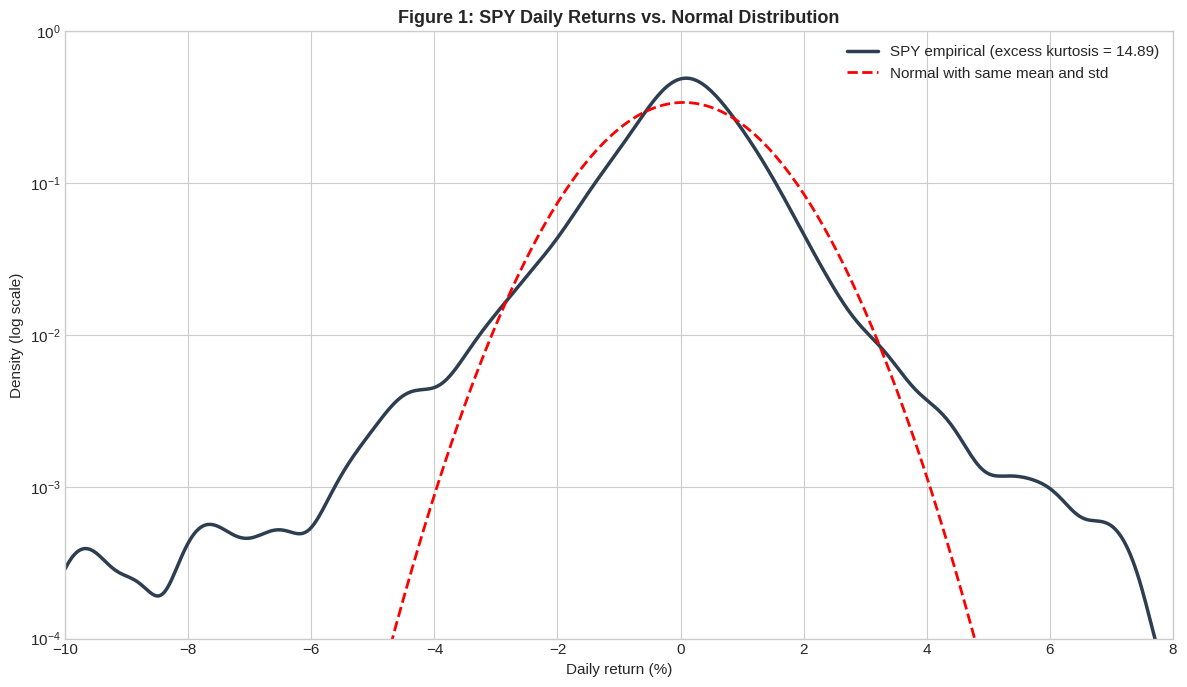

In [8]:
spy_pct = simple_ret['SPY'].values * 100
x_grid = np.linspace(-10, 8, 500)

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(x_grid, gaussian_kde(spy_pct, bw_method=0.3)(x_grid), color='#2c3e50', lw=2.5,
        label=f'SPY empirical (excess kurtosis = {kurtosis(spy_pct):.2f})')
ax.plot(x_grid, norm.pdf(x_grid, spy_pct.mean(), spy_pct.std()), 'r--', lw=2,
        label='Normal with same mean and std')
ax.set_yscale('log')
ax.set_ylim(1e-4, 1)
ax.set_xlim(-10, 8)
ax.set_xlabel('Daily return (%)')
ax.set_ylabel('Density (log scale)')
ax.set_title('Figure 1: SPY Daily Returns vs. Normal Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
save_fig(fig, 'fig01_spy_vs_normal')
plt.show()

The log scale on the y-axis makes the tails visible: far from the mean, the empirical density sits orders of magnitude above the normal curve. That gap is the reason the thesis looks at Expected Shortfall rather than volatility.

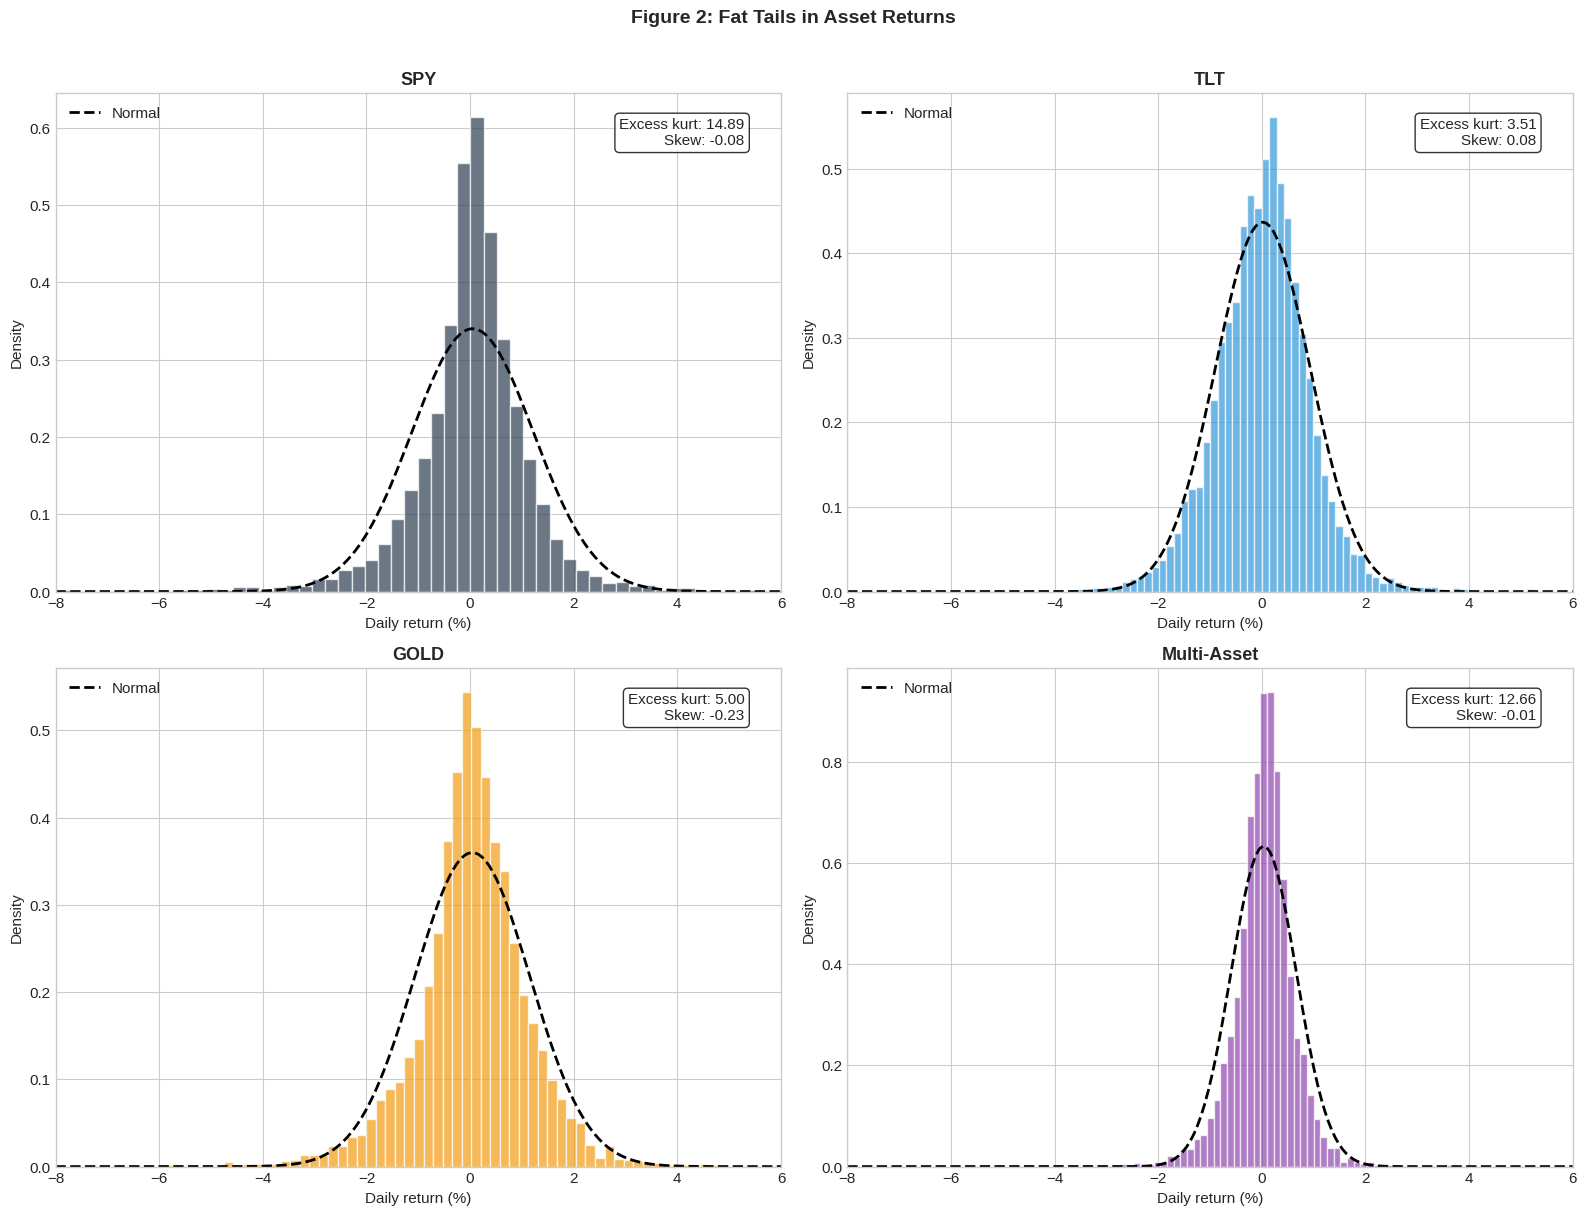

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
panels = [(simple_ret['SPY'].values, 'SPY', '#2c3e50'), (simple_ret['TLT'].values, 'TLT', '#3498db'),
          (simple_ret['GOLD'].values, 'GOLD', '#f39c12'), (ma_ret, 'Multi-Asset', '#8e44ad')]

for ax, (rets, title, color) in zip(axes.flat, panels):
    rets = rets * 100
    ax.hist(rets, bins=100, density=True, alpha=0.7, color=color, edgecolor='white')
    grid = np.linspace(-8, 6, 200)
    ax.plot(grid, norm.pdf(grid, rets.mean(), rets.std()), 'k--', lw=2, label='Normal')
    ax.text(0.95, 0.95, f'Excess kurt: {kurtosis(rets):.2f}\nSkew: {skew(rets):.2f}',
            transform=ax.transAxes, va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_xlim(-8, 6)
    ax.set_xlabel('Daily return (%)')
    ax.set_ylabel('Density')
    ax.set_title(f'{title}', fontweight='bold')
    ax.legend()

fig.suptitle('Figure 2: Fat Tails in Asset Returns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig(fig, 'fig02_return_distributions')
plt.show()

## 3. Regime detection

### 3.1 How many states?

BIC trades off fit against the number of parameters. This comparison is a **diagnostic only**: it uses the full 1994–2024 sample, so nothing from it feeds into the backtest. The walk-forward model below always uses 4 states, which also map naturally onto the four regime names.

In [10]:
def fit_best_hmm(X, n_states, n_inits=HMM_INITS, n_iter=HMM_ITER, seed=SEED):
    """Fit a Gaussian HMM with diagonal covariances from several random starts.

    EM only finds a local optimum, so the model is fitted n_inits times with
    different seeds and the one with the highest log-likelihood is kept.
    Diagonal covariance means each state has its own mean and variance for
    returns and volatility, but no within-state correlation between them.
    This keeps the number of parameters small and the fits stable.
    """
    best_model, best_ll = None, -np.inf
    for i in range(n_inits):
        model = GaussianHMM(n_components=n_states, covariance_type='diag',
                            n_iter=n_iter, random_state=seed + i)
        try:
            model.fit(X)
        except ValueError:
            continue    # rare degenerate start (e.g. a state collapsing); skip it
        ll = model.score(X)
        if ll > best_ll:
            best_model, best_ll = model, ll
    return best_model, best_ll


X_full = StandardScaler().fit_transform(hmm_features[HMM_FEATURES].values)

bic_rows = []
for k in [2, 3, 4]:
    model, ll = fit_best_hmm(X_full, k, n_inits=10, n_iter=1000)
    bic_rows.append({'States': k, 'Log-likelihood': round(ll), 'BIC': round(model.bic(X_full))})

bic_df = pd.DataFrame(bic_rows).set_index('States')
print(f'Lowest BIC: {bic_df["BIC"].idxmin()} states (the walk-forward model uses {N_STATES})')
bic_df

Lowest BIC: 4 states (the walk-forward model uses 4)


,Log-likelihood,BIC
States,,
2,-15360,30818
3,-11970,24119
4,-9850,19977


### 3.2 Walk-forward regime detection

Every January the HMM is refitted on all data before that year (expanding window from 1994) and then used to classify the new year. Three details keep this honest:

1. **Filtered, not smoothed, probabilities.** The regime on day *t* is computed with the forward algorithm, i.e. $P(S_t \mid y_1, \dots, y_t)$, so it only uses data up to day *t*. (hmmlearn's `predict` and `predict_proba` both use the whole sequence, which would leak future information within each year.)
2. **Consistent state labels across refits.** An HMM numbers its states arbitrarily, so "state 2" in one year can be "state 0" the next year. This is called the label-switching problem. The first fit is labelled by sorting states on mean volatility. Every later fit is matched to that first fit by comparing the states' Gaussian distributions, so "Crisis" always describes the same kind of market.
3. **One-day lag for trading.** Strategies act on yesterday's regime.

**How the matching works.** Each state is described by a normal distribution (a mean and a variance for returns and for volatility). The Kullback-Leibler (KL) divergence measures how different two distributions are. KL is not symmetric, so I add both directions. For four states there are only 4! = 24 ways to pair new states with reference states, so the code simply tries all of them and keeps the pairing with the smallest total distance. The comparison is done in the original units, not in standardized units, because every refit uses a new scaler.

In [11]:
def diag_variances(model):
    """Per-state variances as an array of shape (n_states, n_features).

    For covariance_type='diag', hmmlearn's covars_ property still returns full
    (diagonal) matrices, so we take the diagonal of each one.
    """
    covars = np.asarray(model.covars_)
    return np.array([np.diag(c) for c in covars]) if covars.ndim == 3 else covars


def emission_params_original_units(model, scaler):
    """Convert state means and variances from standardized to original units.

    The model is fitted on standardized data (x - mean) / scale. Undoing that
    gives mu = mu_z * scale + mean and var = var_z * scale^2, which makes models
    fitted with different scalers comparable.
    """
    mu = model.means_ * scaler.scale_ + scaler.mean_
    var = diag_variances(model) * scaler.scale_ ** 2
    return mu, var


def kl_divergence_diag(mu1, var1, mu2, var2):
    """KL divergence D_KL(N1 || N2) between two Gaussians with diagonal covariance.

    Closed form for each dimension, summed:
        0.5 * [ var1/var2 + (mu2 - mu1)^2 / var2 - 1 + log(var2/var1) ]
    It is zero when the distributions are identical and grows as means and
    variances drift apart.
    """
    var1 = np.maximum(var1, 1e-12)
    var2 = np.maximum(var2, 1e-12)
    return 0.5 * np.sum(var1 / var2 + (mu2 - mu1) ** 2 / var2 - 1 + np.log(var2 / var1))


def align_states(mu_new, var_new, mu_ref, var_ref):
    """Match the states of a new HMM fit to the states of a reference fit.

    Builds a cost matrix of symmetric KL divergences between every new state
    and every reference state, then tries all permutations and keeps the one
    with the lowest total cost. Returns {new_state: reference_state}.
    """
    n = len(mu_new)
    cost = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            cost[i, j] = (kl_divergence_diag(mu_new[i], var_new[i], mu_ref[j], var_ref[j]) +
                          kl_divergence_diag(mu_ref[j], var_ref[j], mu_new[i], var_new[i]))
    best_perm = min(permutations(range(n)), key=lambda p: sum(cost[i, p[i]] for i in range(n)))
    return {i: best_perm[i] for i in range(n)}


def filtered_probabilities(model, X):
    """Forward algorithm: P(state at t | observations up to t) for every t.

    At each step the previous state probabilities are pushed through the
    transition matrix (prediction) and then reweighted by how likely today's
    observation is in each state (update). Everything is done in log space
    to avoid numerical underflow over thousands of days.
    """
    mu, var = model.means_, diag_variances(model)
    log_b = -0.5 * (np.log(2 * np.pi * var).sum(axis=1)[None, :] +
                    (((X[:, None, :] - mu[None, :, :]) ** 2) / var[None, :, :]).sum(axis=2))
    log_a = np.log(model.transmat_ + 1e-300)
    log_alpha = np.empty_like(log_b)
    a = np.log(model.startprob_ + 1e-300) + log_b[0]
    log_alpha[0] = a - logsumexp(a)
    for t in range(1, len(X)):
        a = logsumexp(log_alpha[t - 1][:, None] + log_a, axis=0) + log_b[t]
        log_alpha[t] = a - logsumexp(a)
    return np.exp(log_alpha)

In [12]:
def walk_forward_regimes(features, first_year, last_year, n_states=N_STATES):
    """Out-of-sample regime labels with yearly refits and stable state labels.

    For each year:
      1. fit a scaler and the HMM on all data before that year,
      2. map the new model's states onto the reference labels (first fit:
         sort by mean volatility; later fits: KL matching to the first fit),
      3. run the forward filter over all data up to the end of the year and
         keep that year's probabilities. Running the filter from the start
         (instead of from 1 January) carries the regime information over the
         turn of the year; it is still causal.
    Returns a Series of integer labels and a DataFrame of probabilities.
    """
    labels = pd.Series(np.nan, index=features.index)
    probs = pd.DataFrame(np.nan, index=features.index, columns=REGIME_NAMES)
    ref_mu = ref_var = ref_mapping = None

    for year in tqdm(range(first_year, last_year + 1), desc='Walk-forward HMM'):
        train = features[features.index.year < year].values
        scaler = StandardScaler().fit(train)
        model, _ = fit_best_hmm(scaler.transform(train), n_states)
        mu, var = emission_params_original_units(model, scaler)

        if ref_mu is None:
            order = np.argsort(mu[:, 1])          # sort states by mean volatility
            ref_mapping = {int(raw): label for label, raw in enumerate(order)}
            ref_mu, ref_var = mu, var
            mapping = ref_mapping
        else:
            raw_to_ref = align_states(mu, var, ref_mu, ref_var)
            mapping = {new: ref_mapping[ref] for new, ref in raw_to_ref.items()}

        upto = features[features.index.year <= year]
        p_raw = filtered_probabilities(model, scaler.transform(upto.values))
        in_year = (upto.index.year == year)
        p_aligned = np.zeros((in_year.sum(), n_states))
        for raw_state, label in mapping.items():
            p_aligned[:, label] = p_raw[in_year, raw_state]

        idx = upto.index[in_year]
        probs.loc[idx] = p_aligned
        labels.loc[idx] = p_aligned.argmax(axis=1)

    return labels, probs, model, scaler


last_year = hmm_features.index[-1].year
regime_int, regime_probs, final_model, final_scaler = walk_forward_regimes(
    hmm_features[HMM_FEATURES], FIRST_OOS_YEAR, last_year)

regime_int = regime_int.dropna().astype(int)
regime = regime_int.map(dict(enumerate(REGIME_NAMES)))

# Sanity check: at the very last observation the filtered and the smoothed
# (forward-backward) probability must coincide, because there is no future data.
X_check = final_scaler.transform(hmm_features[HMM_FEATURES].values)
assert np.allclose(filtered_probabilities(final_model, X_check)[-1],
                   final_model.predict_proba(X_check)[-1], atol=1e-6)

regime_counts = regime.value_counts().reindex(REGIME_NAMES)
pd.DataFrame({'Days': regime_counts, 'Share (%)': (regime_counts / len(regime) * 100).round(1)})

,Days,Share (%)
Low Vol,2176,43.2
Normal,1306,25.9
High Vol,930,18.5
Crisis,621,12.3


### 3.3 Transition matrix and regime duration

Entry $P_{ij}$ is the empirical probability of moving from regime *i* today to regime *j* tomorrow. The expected time spent in a regime is $1 / (1 - P_{ii})$. The matrix and its stationary distribution are also the engine of the Monte Carlo simulation in section 7.

In [13]:
states = regime_int.values
counts = np.zeros((N_STATES, N_STATES))
for a, b in zip(states[:-1], states[1:]):
    counts[a, b] += 1
transition_matrix = counts / np.maximum(counts.sum(axis=1, keepdims=True), 1)

# Stationary distribution: the left eigenvector of P for eigenvalue 1
eig_vals, eig_vecs = np.linalg.eig(transition_matrix.T)
stationary = np.abs(np.real(eig_vecs[:, np.argmin(np.abs(eig_vals - 1))]))
stationary /= stationary.sum()

p_stay = np.diag(transition_matrix)
duration_df = pd.DataFrame({'P(stay)': p_stay.round(4),
                            'Expected duration (days)': (1 / np.maximum(1 - p_stay, 1e-10)).round(1),
                            'Stationary share': stationary.round(3)}, index=REGIME_NAMES)

display(pd.DataFrame(transition_matrix, index=REGIME_NAMES, columns=REGIME_NAMES).round(4))
duration_df

,Low Vol,Normal,High Vol,Crisis
Low Vol,0.9761,0.0234,0.0000,0.0005
Normal,0.0391,0.9356,0.0245,0.0008
High Vol,0.0000,0.0355,0.9484,0.0161
Crisis,0.0000,0.0016,0.0258,0.9726


,P(stay),Expected duration (days),Stationary share
Low Vol,0.9761,41.8,0.428
Normal,0.9356,15.5,0.262
High Vol,0.9484,19.4,0.186
Crisis,0.9726,36.5,0.124


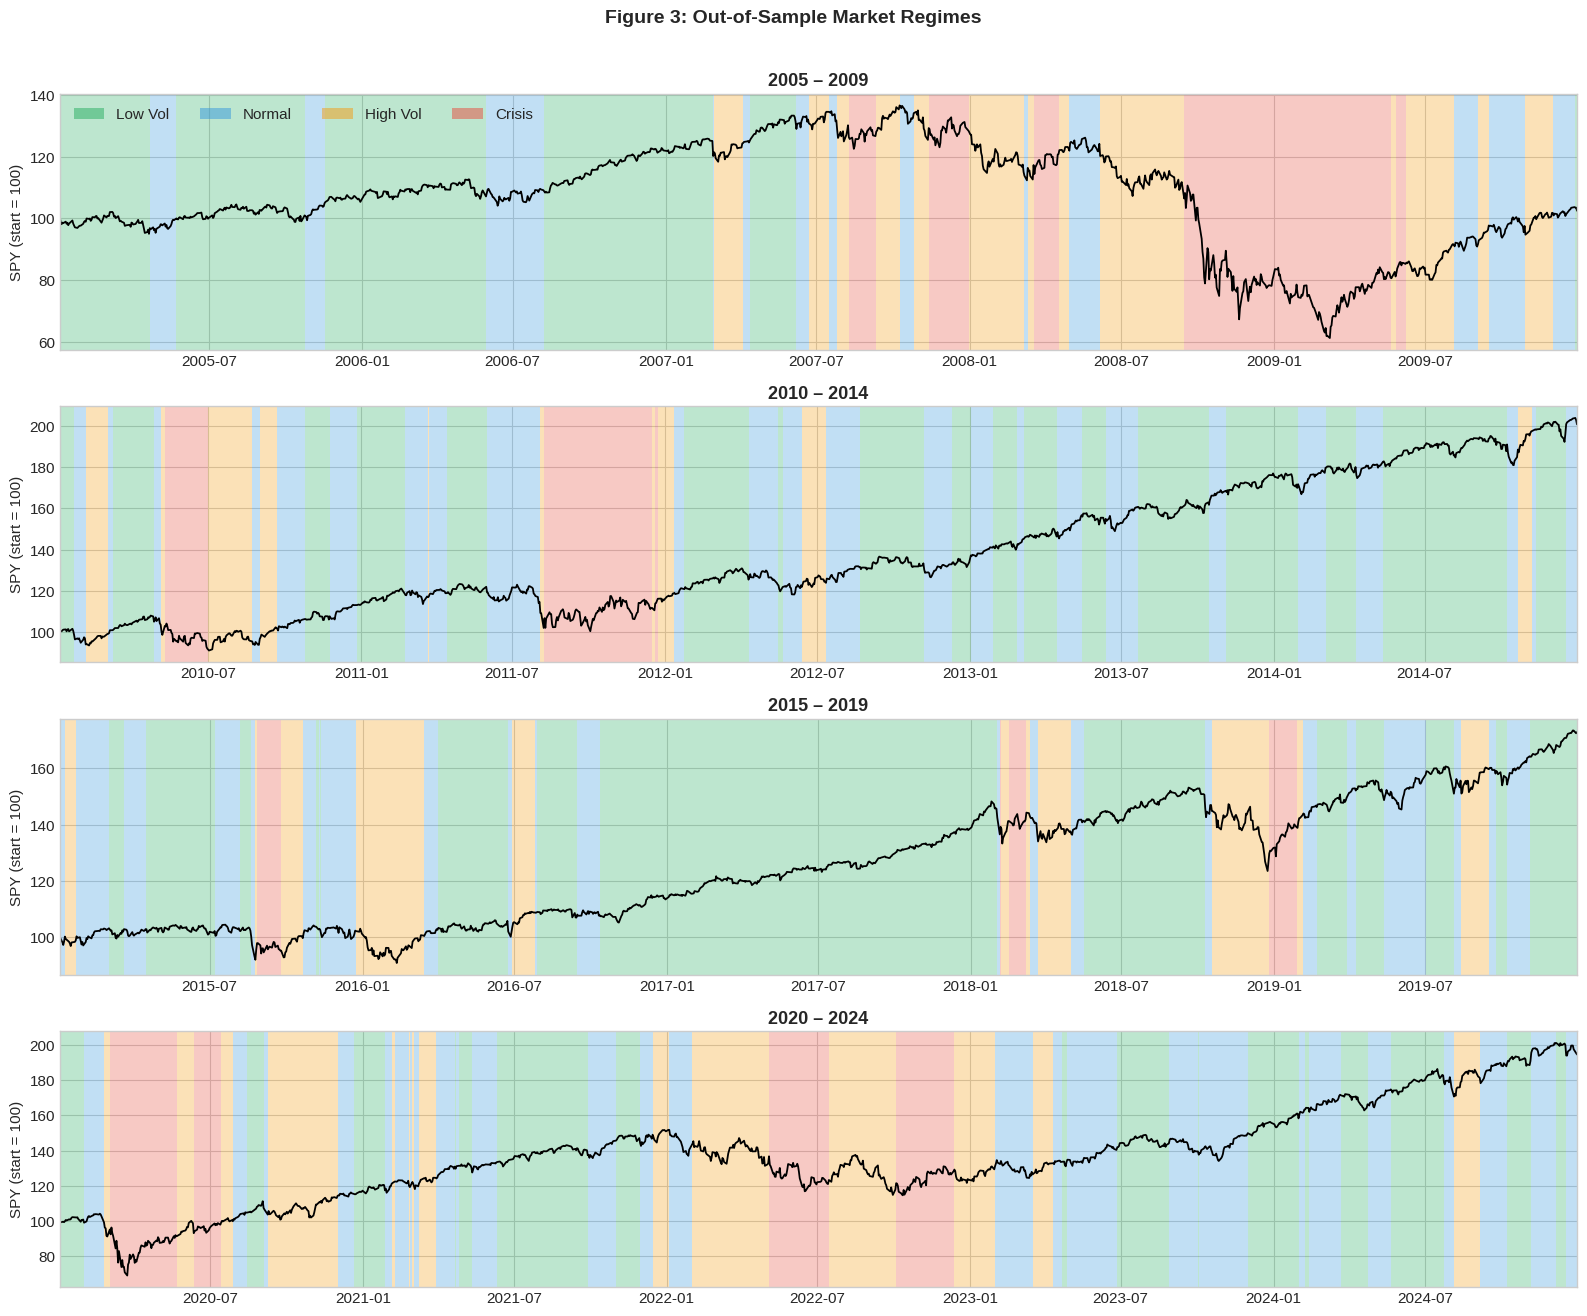

In [14]:
def shade_regimes(ax, regime_series):
    """Shade the background of a time-series plot by regime.

    Consecutive days in the same regime are merged into one block, which is
    much faster to draw than one rectangle per day.
    """
    change = regime_series.ne(regime_series.shift())
    starts = list(regime_series.index[change]) + [regime_series.index[-1] + pd.Timedelta(days=1)]
    labels = regime_series[change].values
    # each block runs until the next block starts, so weekends don't leave white gaps
    for start, end, label in zip(starts[:-1], starts[1:], labels):
        ax.axvspan(start, end, color=REGIME_COLORS[label], alpha=0.3, lw=0)


years_all = np.arange(regime.index.year.min(), regime.index.year.max() + 1)
chunks = np.array_split(years_all, 4)

fig, axes = plt.subplots(4, 1, figsize=(16, 13))
for ax, yrs in zip(axes, chunks):
    mask = regime.index.year.isin(yrs)
    reg_panel = regime[mask]
    spy_panel = spy_long.reindex(reg_panel.index)
    shade_regimes(ax, reg_panel)
    ax.plot(spy_panel.index, spy_panel / spy_panel.iloc[0] * 100, color='black', lw=1.3)
    ax.set_title(f'{yrs[0]} – {yrs[-1]}', fontweight='bold')
    ax.set_ylabel('SPY (start = 100)')
    ax.set_xlim(reg_panel.index[0], reg_panel.index[-1])

axes[0].legend(handles=[Patch(facecolor=REGIME_COLORS[r], alpha=0.5, label=r) for r in REGIME_NAMES],
               loc='upper left', ncol=4)
fig.suptitle('Figure 3: Out-of-Sample Market Regimes', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig(fig, 'fig03_regime_timeline')
plt.show()

### 3.4 What the regimes look like

The table below is descriptive: it uses all out-of-sample days at once. The strategies never see it; Tail-Risk Parity estimates its own regime statistics from past data only (section 4).

In [15]:
reg_days = regime.index.intersection(simple_ret.index)
reg_ret = simple_ret.loc[reg_days]
reg_lab = regime.loc[reg_days]

regime_rows = []
for name in REGIME_NAMES:
    r = reg_ret[reg_lab == name]
    if len(r) < 20:
        continue
    regime_rows.append({'Regime': name, 'Days': len(r),
                        'SPY ES 99% (%)': round(expected_shortfall(r['SPY']) * 100, 2),
                        'SPY excess kurtosis': round(kurtosis(r['SPY']), 2),
                        'SPY skewness': round(skew(r['SPY']), 2),
                        'SPY ann. vol (%)': round(r['SPY'].std() * np.sqrt(252) * 100, 1),
                        'SPY-TLT correlation': round(r['SPY'].corr(r['TLT']), 2)})
regime_stats_df = pd.DataFrame(regime_rows).set_index('Regime')
regime_stats_df

,Days,SPY ES 99% (%),SPY excess kurtosis,SPY skewness,SPY ann. vol (%),SPY-TLT correlation
Regime,,,,,,
Low Vol,2176,1.86,0.95,-0.33,9.5,-0.20
Normal,1306,2.84,0.88,-0.45,14.3,-0.24
High Vol,930,3.86,0.67,-0.42,20.0,-0.31
Crisis,621,8.90,4.02,0.12,39.9,-0.46


Tail losses grow steadily with the regime: SPY's ES 99% rises from about 1.9% in Low Vol to almost 9% in Crisis. Excess kurtosis only jumps in the Crisis regime; within the calmer regimes returns are close to normal.

The SPY–TLT correlation is negative in every regime and even more negative in stress, so on average long bonds were a good hedge in crises over 2005–2024. 2022 is the exception: with inflation driving rates up, stocks and bonds fell together. Drawdown Control still moves part of its non-equity weight from TLT to Gold and SHY in stressed regimes. That gives up some of the usual bond hedge in exchange for protection in a 2022-type market.

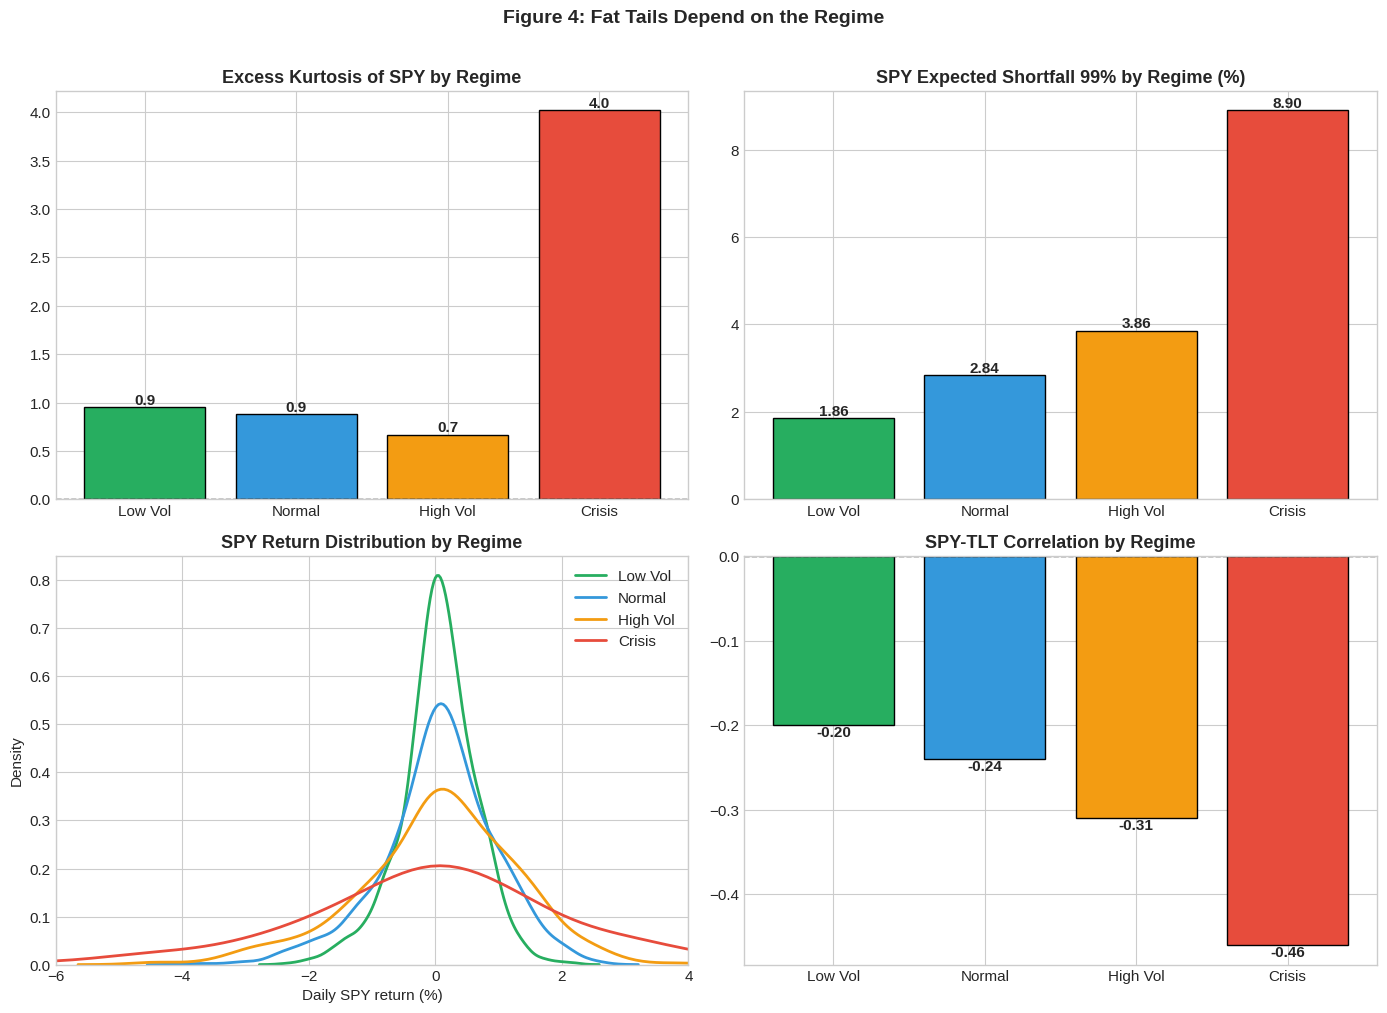

In [16]:
names_present = regime_stats_df.index.tolist()
bar_colors = [REGIME_COLORS[r] for r in names_present]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
vals = regime_stats_df['SPY excess kurtosis']
ax.bar(names_present, vals, color=bar_colors, edgecolor='black')
ax.axhline(0, color='black', ls='--', lw=1)
ax.set_title('Excess Kurtosis of SPY by Regime', fontweight='bold')
for i, v in enumerate(vals):
    ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')

ax = axes[0, 1]
vals = regime_stats_df['SPY ES 99% (%)']
ax.bar(names_present, vals, color=bar_colors, edgecolor='black')
ax.set_title('SPY Expected Shortfall 99% by Regime (%)', fontweight='bold')
for i, v in enumerate(vals):
    ax.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

ax = axes[1, 0]
for name in names_present:
    sns.kdeplot(reg_ret.loc[reg_lab == name, 'SPY'] * 100, ax=ax, label=name,
                color=REGIME_COLORS[name], lw=2)
ax.set_xlim(-6, 4)
ax.set_xlabel('Daily SPY return (%)')
ax.set_title('SPY Return Distribution by Regime', fontweight='bold')
ax.legend()

ax = axes[1, 1]
vals = regime_stats_df['SPY-TLT correlation']
ax.bar(names_present, vals, color=bar_colors, edgecolor='black')
ax.axhline(0, color='black', ls='--', lw=1)
ax.set_title('SPY-TLT Correlation by Regime', fontweight='bold')
for i, v in enumerate(vals):
    ax.text(i, v, f'{v:.2f}', ha='center', va='bottom' if v >= 0 else 'top', fontweight='bold')

fig.suptitle('Figure 4: Fat Tails Depend on the Regime', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig(fig, 'fig04_regime_fat_tails')
plt.show()

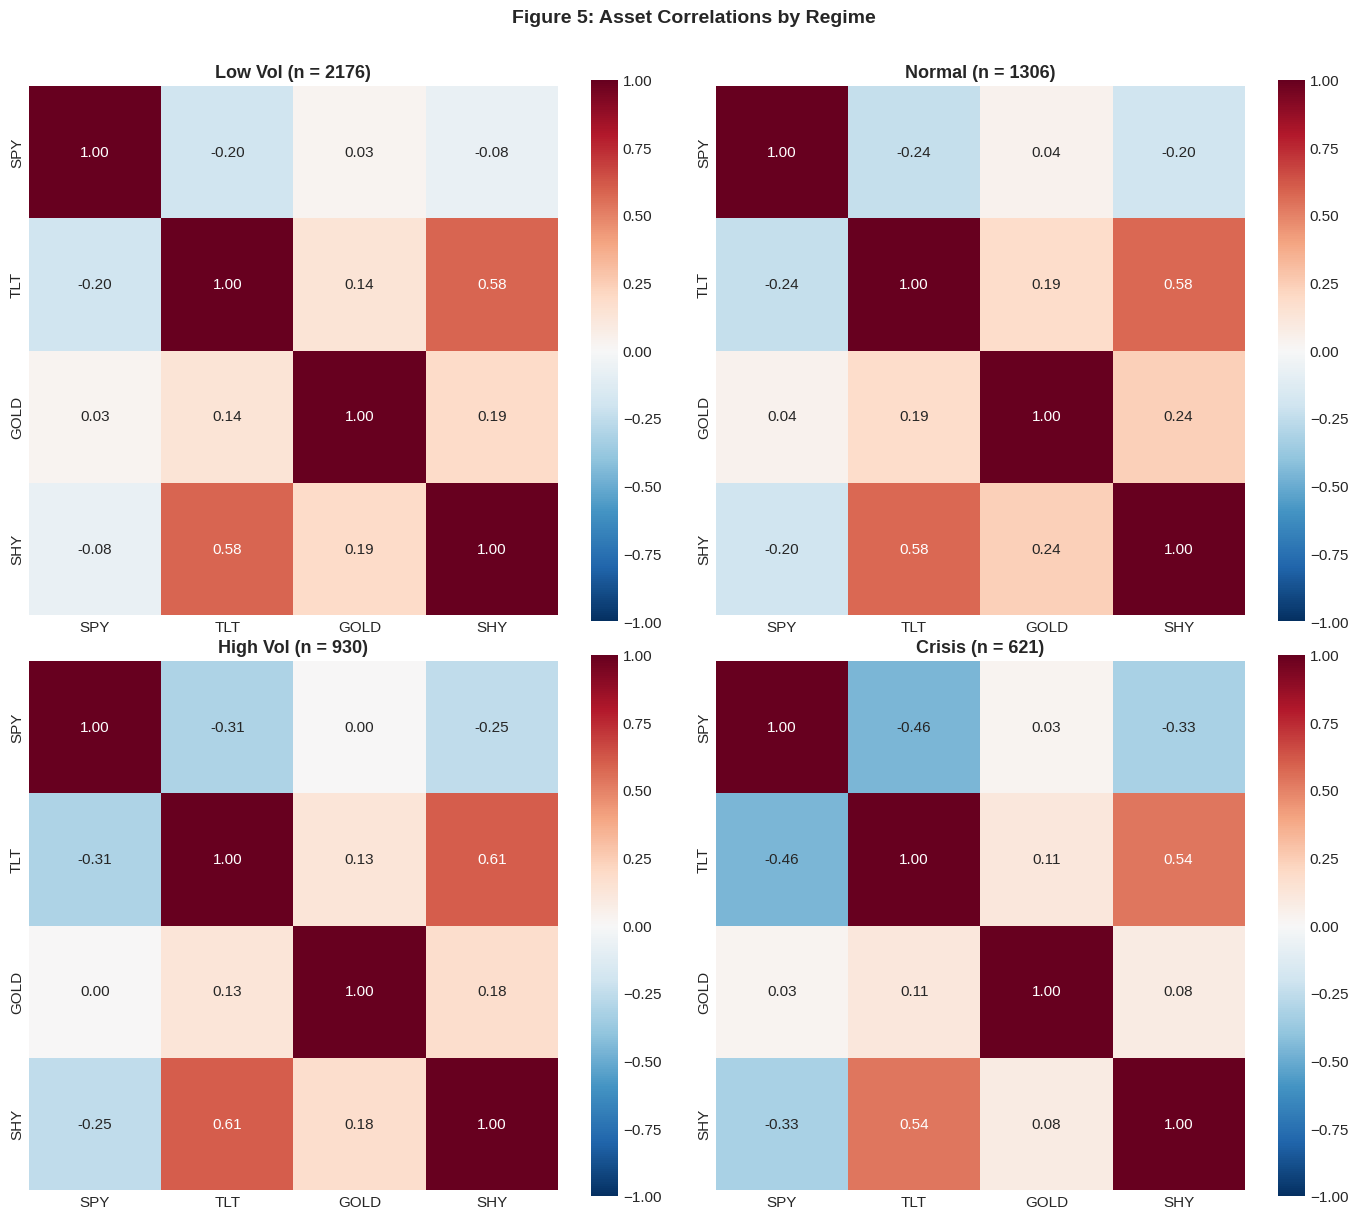

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, name in zip(axes.flat, REGIME_NAMES):
    r = reg_ret[reg_lab == name]
    if len(r) < 50:
        ax.set_visible(False)
        continue
    sns.heatmap(r.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                ax=ax, square=True)
    ax.set_title(f'{name} (n = {len(r)})', fontweight='bold')

fig.suptitle('Figure 5: Asset Correlations by Regime', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig(fig, 'fig05_regime_correlations')
plt.show()

## 4. Strategies

All strategies share the same interface so that exactly the same code runs in the backtest and in the Monte Carlo simulation:

- `R`: array of daily simple returns, columns in the order SPY, TLT, GOLD, SHY
- `reg`: regime known at the start of each day, i.e. yesterday's label (integers 0–3)

Each strategy decides its weights at the start of day *t* using only information up to *t − 1*, earns the return of day *t*, and pays transaction costs on weight changes. Each returns the daily portfolio returns and the equity weight.

In [18]:
def split_weights(spy_w, regime_name):
    """Turn an equity weight into a full weight vector [SPY, TLT, GOLD, SHY].

    The equity weight is clipped to [MIN_EQUITY, MAX_EQUITY]; the rest is split
    between TLT, GOLD and SHY according to the regime (SAFE_SPLIT).
    """
    spy_w = min(max(spy_w, MIN_EQUITY), MAX_EQUITY)
    rem = 1.0 - spy_w
    tlt, gold, shy = SAFE_SPLIT[regime_name]
    return spy_w, rem * tlt, rem * gold, rem * shy

### Benchmarks

The two buy-and-hold benchmarks hold fixed weights and are rebalanced back to them every day (so "B&H Multi-Asset" is technically a constant-mix portfolio). Daily drift rebalancing is not charged transaction costs for any strategy, so the comparison stays fair.

In [19]:
def strategy_static(R, weights):
    """Fixed-weight portfolio, rebalanced daily to its target weights.

    Used for both benchmarks: 100% SPY and the 55/25/10/10 multi-asset mix.
    """
    w = np.array([weights.get(a, 0.0) for a in ASSETS])
    return R @ w, np.full(len(R), w[0])

### Mean-variance benchmark

The classic Markowitz approach and the most common reference point in portfolio research. Once a month the strategy estimates mean returns and the covariance matrix from the last three years of daily returns and picks the long-only portfolio with the highest Sharpe ratio (the tangency portfolio). It is dynamic, like the regime strategies, but it knows nothing about regimes or tails: it only sees means and variances. That makes it a fair test of whether regime-awareness adds something beyond regular re-estimation.

**How the optimization is solved.** With only four assets there are 15 possible sets of assets the portfolio can hold. For each set, the unconstrained tangency portfolio is $w \propto \Sigma^{-1}(\mu - r_f)$. Among the sets where all weights come out positive, the one with the highest Sharpe ratio is the exact long-only optimum. This is much faster than a numerical optimizer, which matters because the Monte Carlo simulation runs it hundreds of thousands of times. If no portfolio has a positive expected excess return, the strategy holds the long-only minimum-variance portfolio instead.

In [20]:
ASSET_SUBSETS = [list(c) for k in range(1, len(ASSETS) + 1)
                 for c in combinations(range(len(ASSETS)), k)]


def _best_subset_portfolio(cov, target, score):
    """Try the closed-form solution w ∝ Σ⁻¹ · target on every subset of assets.

    Keeps only solutions with strictly positive weights (long-only) and
    returns the one with the best score, or None if no subset works.
    """
    best_w, best_score = None, -np.inf
    for S in ASSET_SUBSETS:
        try:
            y = np.linalg.solve(cov[np.ix_(S, S)], target[S])
        except np.linalg.LinAlgError:
            continue
        if (y <= 0).any():
            continue
        w = np.zeros(len(target))
        w[S] = y / y.sum()
        sc = score(w)
        if sc > best_score:
            best_w, best_score = w, sc
    return best_w


def max_sharpe_weights(mu_excess, cov):
    """Long-only, fully invested portfolio with the highest Sharpe ratio.

    mu_excess: expected daily returns minus the daily risk-free rate.
    Falls back to the long-only minimum-variance portfolio when no
    portfolio has a positive expected excess return.
    """
    w = _best_subset_portfolio(cov, mu_excess,
                               lambda w: (w @ mu_excess) / np.sqrt(w @ cov @ w))
    if w is None or w @ mu_excess <= 0:
        w = _best_subset_portfolio(cov, np.ones(len(mu_excess)), lambda w: -(w @ cov @ w))
    return w


def strategy_mean_variance(R, R_pre=None):
    """Monthly re-optimized maximum-Sharpe portfolio (long-only Markowitz).

    Every MV_REBALANCE days, means and covariances are estimated from the
    last MV_WINDOW days and the weights are re-optimized. Until MV_MIN_OBS
    days of history exist, it holds the static multi-asset weights.
    R_pre is optional history before the first trading day; it is only used
    for estimation, which lets the backtest start with a full window.
    Transaction costs are charged on every re-optimization.
    """
    hist = R if R_pre is None else np.vstack([R_pre, R])
    offset = len(hist) - len(R)
    rf_daily = RF_RATE / 252
    n = len(R)
    rets, eq = np.zeros(n), np.zeros(n)
    w = np.array([MA_WEIGHTS[a] for a in ASSETS])
    w_prev = w

    for t in range(n):
        if t % MV_REBALANCE == 0:
            end = offset + t
            window = hist[max(0, end - MV_WINDOW):end]
            if len(window) >= MV_MIN_OBS:
                w = max_sharpe_weights(window.mean(axis=0) - rf_daily, np.cov(window, rowvar=False))
        rets[t] = R[t] @ w - TC_ETF * np.abs(w - w_prev).sum()
        eq[t] = w[0]
        w_prev = w
    return rets, eq

### Tail-Risk Parity

Classic risk parity gives each asset a weight proportional to 1 / volatility, so every asset contributes a similar amount of risk. Here volatility is replaced by Expected Shortfall, and the ES is measured within the current regime: an asset's ES on days that followed a "Crisis" signal is very different from its ES on calm days. When the regime turns stressed, SPY's tail risk rises much more than that of TLT or Gold, so the equity weight falls on its own, without a separate rule.

The risk budget is shared only between the risky assets: SPY, TLT and Gold. SHY (1–3 year Treasuries) is almost cash, with a daily ES of a few basis points. If it were included, 1 / ES would hand it most of the portfolio and push equity to its floor permanently, which is a known pitfall of naive risk parity with a near-riskless asset. SHY therefore gets no weight in this strategy.

To avoid look-ahead bias, the regime-conditional ES table is re-estimated every quarter from past returns only. Until a regime has been observed for at least `MIN_REGIME_OBS` days, the strategy falls back to the trailing 63-day ES, and before that to the benchmark weights.

In [21]:
def regime_es_table(R_hist, reg_hist):
    """ES 99% of each asset in each regime, estimated from past data only.

    Rows are regimes, columns are assets. A regime with fewer than
    MIN_REGIME_OBS past days gets NaN, so the strategy knows to fall back.
    """
    table = np.full((N_STATES, R_hist.shape[1]), np.nan)
    for s in range(N_STATES):
        mask = reg_hist == s
        if mask.sum() >= MIN_REGIME_OBS:
            table[s] = expected_shortfall(R_hist[mask])
    return table


def inverse_es_weights(es):
    """Inverse-ES weights for the risky assets, returned as [SPY, TLT, GOLD, SHY].

    SPY, TLT and GOLD get weights proportional to 1 / ES (each floored at
    0.1% so a tiny estimate can't explode). SHY gets zero. If the SPY weight
    falls below MIN_EQUITY, it is raised to the floor and TLT and GOLD are
    scaled down proportionally so the weights still sum to one.
    """
    inv = 1.0 / np.maximum(es[:3], 1e-3)
    spy, tlt, gold = inv / inv.sum()
    if spy < MIN_EQUITY:
        scale = (1.0 - MIN_EQUITY) / (tlt + gold)
        spy, tlt, gold = MIN_EQUITY, tlt * scale, gold * scale
    return spy, tlt, gold, 0.0


def strategy_tail_risk_parity(R, reg):
    """Inverse-ES weighting of SPY, TLT and Gold with regime-conditional ES.

    Each day:
      1. look up the ES of every asset for the current regime
         (re-estimated every ES_REFRESH days from past data only;
         trailing ES or benchmark weights while there is too little history),
      2. weight SPY, TLT and GOLD by 1 / ES (see inverse_es_weights),
      3. pay transaction costs on the change in weights.
    """
    n = len(R)
    rets, eq = np.zeros(n), np.zeros(n)
    w_static = tuple(MA_WEIGHTS[a] for a in ASSETS)
    w_prev = w_static
    es_table = np.full((N_STATES, len(ASSETS)), np.nan)
    rows = R.tolist()

    for t in range(n):
        if t > 0 and t % ES_REFRESH == 0:
            es_table = regime_es_table(R[:t], reg[:t])
        s = reg[t]

        if not np.isnan(es_table[s, 0]):
            w = inverse_es_weights(es_table[s])
        elif t >= ES_FALLBACK_WINDOW:
            w = inverse_es_weights(expected_shortfall(R[t - ES_FALLBACK_WINDOW:t]))
        else:
            w = w_static

        cost = TC_ETF * sum(abs(a - b) for a, b in zip(w, w_prev))
        r = rows[t]
        rets[t] = w[0] * r[0] + w[1] * r[1] + w[2] * r[2] + w[3] * r[3] - cost
        eq[t] = w[0]
        w_prev = w
    return rets, eq

### Drawdown Control

A CPPI-style rule. Each regime has a base equity weight and a drawdown threshold. Once the portfolio falls further below its high-water mark than the threshold allows, a convex penalty cuts equity; the cut is stronger in more severe regimes. On top of that, a kurtosis brake reduces equity when the trailing one-year kurtosis of SPY is extreme.

In [22]:
def strategy_drawdown_control(R, reg, kurt_lag):
    """Regime-based equity target with a drawdown penalty and a kurtosis brake.

    Each day:
      1. drawdown = how far the portfolio is below its high-water mark,
      2. if drawdown exceeds the regime threshold, penalty
         = min(1, 0.3 * ((drawdown - threshold) / threshold) ^ 1.5),
         which starts at zero and grows faster the deeper the drawdown,
      3. equity = regime base weight * (1 - severity * penalty), where
         severity is higher in stressed regimes,
      4. if the trailing 252-day excess kurtosis of SPY (known yesterday)
         is above KURT_BRAKE, cut equity by up to another 30%,
      5. split the rest by regime and pay transaction costs.
    """
    n = len(R)
    rets, eq = np.zeros(n), np.zeros(n)
    value, peak = 1.0, 1.0
    w_prev = None
    rows = R.tolist()

    for t in range(n):
        name = REGIME_NAMES[reg[t]]
        peak = max(peak, value)
        dd = 1.0 - value / peak
        thr = DD_THRESHOLDS[name]
        penalty = min(1.0, 0.3 * ((dd - thr) / thr) ** 1.5) if dd > thr else 0.0
        target = REGIME_EQUITY[name] * (1.0 - PENALTY_SEVERITY[name] * penalty)

        k = kurt_lag[t]
        if k > KURT_BRAKE:
            target *= 1.0 - min(0.3, (k - KURT_BRAKE) / 20)

        w = split_weights(target, name)
        cost = 0.0 if w_prev is None else TC_ETF * sum(abs(a - b) for a, b in zip(w, w_prev))
        r = rows[t]
        rets[t] = w[0] * r[0] + w[1] * r[1] + w[2] * r[2] + w[3] * r[3] - cost
        value *= 1.0 + rets[t]
        eq[t] = w[0]
        w_prev = w
    return rets, eq

## 5. Backtest results

The backtest starts on the first day with an out-of-sample regime signal (early January 2005) and runs to the end of 2024.

In [23]:
regime_lag = regime_int.shift(1)    # the regime we know at the start of each day
bt_index = simple_ret.index[simple_ret.index.isin(regime_lag.dropna().index)]

R_bt = simple_ret.loc[bt_index, ASSETS].values
reg_bt = regime_lag.loc[bt_index].astype(int).values
kurt_lag_bt = simple_ret['SPY'].rolling(252).kurt().shift(1).reindex(bt_index).fillna(0.0).values


def run_strategies(R, reg, kurt_lag, R_pre=None, include_spy=True):
    """Run every strategy on the same inputs and return {name: (returns, equity weights)}."""
    out = {}
    if include_spy:
        out['B&H SPY'] = strategy_static(R, {'SPY': 1.0})
    out['B&H Multi-Asset'] = strategy_static(R, MA_WEIGHTS)
    out['Mean-Variance'] = strategy_mean_variance(R, R_pre)
    out['Tail-Risk Parity'] = strategy_tail_risk_parity(R, reg)
    out['Drawdown Control'] = strategy_drawdown_control(R, reg, kurt_lag)
    return out


# returns before the backtest start (2003-2004), used only to estimate the first mean-variance weights
R_pre_bt = simple_ret.loc[simple_ret.index < bt_index[0], ASSETS].values

results = run_strategies(R_bt, reg_bt, kurt_lag_bt, R_pre=R_pre_bt)
returns_df = pd.DataFrame({k: v[0] for k, v in results.items()}, index=bt_index)
equity_df = pd.DataFrame({k: v[1] for k, v in results.items()}, index=bt_index)

print(f'Backtest: {bt_index[0]:%Y-%m-%d} to {bt_index[-1]:%Y-%m-%d} ({len(bt_index)} days)')

Backtest: 2005-01-04 to 2024-12-31 (5032 days)


In [24]:
def calculate_metrics(rets):
    """Risk and return metrics for a series of daily simple returns.

    - Annual return: geometric (CAGR).
    - Sharpe: (CAGR - risk-free rate) / annualized volatility.
    - Sortino: same, but divided by downside deviation (only negative days count).
    - Tail ratio: 95th percentile / |5th percentile|; above 1 means the right
      tail is bigger than the left.
    - CVaR 95% / 99%: Expected Shortfall at those levels.
    - Max drawdown: worst peak-to-trough fall of the cumulative value.
    """
    rets = np.asarray(rets)
    rets = rets[~np.isnan(rets)]
    n = len(rets)
    wealth = np.cumprod(1 + rets)
    cagr = wealth[-1] ** (252 / n) - 1
    vol = rets.std() * np.sqrt(252)
    downside = np.sqrt(np.mean(np.minimum(rets, 0) ** 2)) * np.sqrt(252)
    q95, q05 = np.percentile(rets, [95, 5])
    max_dd = (wealth / np.maximum.accumulate(wealth) - 1).min()
    return {
        'Annual Return (%)': round(cagr * 100, 2),
        'Volatility (%)': round(vol * 100, 2),
        'Sharpe': round((cagr - RF_RATE) / vol, 3) if vol > 0 else 0.0,
        'Sortino': round((cagr - RF_RATE) / downside, 3) if downside > 0 else 0.0,
        'Kurtosis': round(kurtosis(rets), 2),
        'Skewness': round(skew(rets), 3),
        'Tail Ratio': round(abs(q95 / q05), 3) if abs(q05) > 1e-12 else 1.0,
        'CVaR 95% (%)': round(expected_shortfall(rets, 0.95) * 100, 2),
        'CVaR 99% (%)': round(expected_shortfall(rets, 0.99) * 100, 2),
        'Max Drawdown (%)': round(max_dd * 100, 1),
    }


metrics_df = pd.DataFrame({name: calculate_metrics(returns_df[name]) for name in STRATEGIES}).T
metrics_df.index.name = 'Strategy'
metrics_df

,Annual Return (%),Volatility (%),Sharpe,Sortino,Kurtosis,Skewness,Tail Ratio,CVaR 95% (%),CVaR 99% (%),Max Drawdown (%)
Strategy,,,,,,,,,,
B&H SPY,10.31,19.03,0.437,0.614,14.93,-0.080,0.928,2.93,5.11,-55.2
B&H Multi-Asset,8.52,10.20,0.639,0.915,12.79,0.003,1.009,1.51,2.59,-27.5
Mean-Variance,7.77,8.61,0.670,0.937,7.21,-0.612,1.010,1.37,2.25,-24.9
Tail-Risk Parity,7.86,8.82,0.665,0.954,3.92,-0.224,0.969,1.27,1.93,-25.4
Drawdown Control,8.67,7.86,0.848,1.217,3.10,-0.268,0.988,1.14,1.78,-18.4


In [25]:
def deltas_vs_benchmark(metrics, strategies, benchmark=BENCHMARK):
    """Differences between each dynamic strategy and the benchmark.

    Negative CVaR and kurtosis deltas are improvements; for Sharpe, skewness
    and tail ratio, positive deltas are improvements.
    """
    bm = metrics.loc[benchmark]
    rows = []
    for name in strategies:
        m = metrics.loc[name]
        rows.append({'Strategy': name,
                     'CVaR 99% Δ (pp)': round(m['CVaR 99% (%)'] - bm['CVaR 99% (%)'], 2),
                     'CVaR 99% Δ (%)': round((m['CVaR 99% (%)'] / bm['CVaR 99% (%)'] - 1) * 100, 1),
                     'Kurtosis Δ (%)': round((m['Kurtosis'] / bm['Kurtosis'] - 1) * 100, 1),
                     'Sharpe Δ': round(m['Sharpe'] - bm['Sharpe'], 3),
                     'Skew Δ': round(m['Skewness'] - bm['Skewness'], 3),
                     'Tail Ratio Δ': round(m['Tail Ratio'] - bm['Tail Ratio'], 3),
                     'Max DD Δ (pp)': round(m['Max Drawdown (%)'] - bm['Max Drawdown (%)'], 1)})
    return pd.DataFrame(rows).set_index('Strategy')


print(f'vs. {BENCHMARK}')
display(deltas_vs_benchmark(metrics_df, DYNAMIC_STRATEGIES, BENCHMARK))
print('vs. Mean-Variance')
display(deltas_vs_benchmark(metrics_df, DYNAMIC_STRATEGIES, 'Mean-Variance'))

vs. B&H Multi-Asset


,CVaR 99% Δ (pp),CVaR 99% Δ (%),Kurtosis Δ (%),Sharpe Δ,Skew Δ,Tail Ratio Δ,Max DD Δ (pp)
Strategy,,,,,,,
Tail-Risk Parity,-0.66,-25.5,-69.4,0.026,-0.227,-0.040,2.1
Drawdown Control,-0.81,-31.3,-75.8,0.209,-0.271,-0.021,9.1


vs. Mean-Variance


,CVaR 99% Δ (pp),CVaR 99% Δ (%),Kurtosis Δ (%),Sharpe Δ,Skew Δ,Tail Ratio Δ,Max DD Δ (pp)
Strategy,,,,,,,
Tail-Risk Parity,-0.32,-14.2,-45.6,-0.005,0.388,-0.041,-0.5
Drawdown Control,-0.47,-20.9,-57.0,0.178,0.344,-0.022,6.5


How much equity does each strategy actually hold? This helps to separate "the strategy is smarter" from "the strategy simply holds less equity".

In [26]:
exposure_rows = []
for name in STRATEGIES:
    w = equity_df[name]
    exposure_rows.append({'Strategy': name,
                          'Avg equity weight': round(w.mean(), 3),
                          'Min': round(w.min(), 3), 'Max': round(w.max(), 3),
                          'Days with equity at or below 20% (%)': round((w <= MIN_EQUITY + 1e-9).mean() * 100, 1)})
pd.DataFrame(exposure_rows).set_index('Strategy')

,Avg equity weight,Min,Max,Days with equity at or below 20% (%)
Strategy,,,,
B&H SPY,1.000,1.000,1.00,0.0
B&H Multi-Asset,0.550,0.550,0.55,0.0
Mean-Variance,0.408,0.009,1.00,27.5
Tail-Risk Parity,0.324,0.200,0.55,5.5
Drawdown Control,0.475,0.200,0.60,12.9


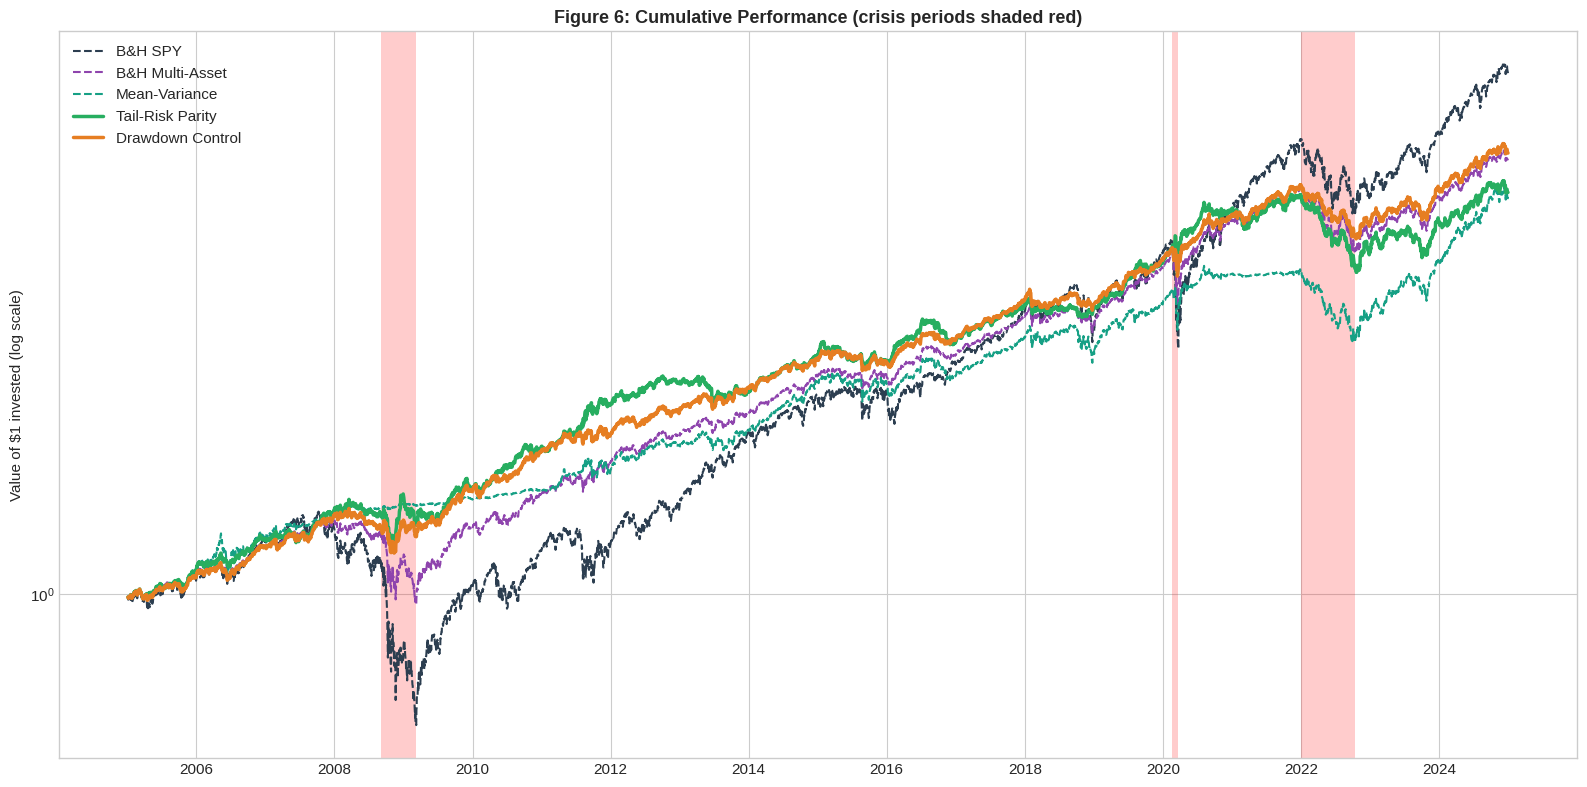

In [27]:
def shade_crises(ax, alpha=0.15):
    """Shade the predefined crisis periods in red."""
    for _, start, end in CRISES:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color='red', alpha=alpha, lw=0)


wealth_df = (1 + returns_df).cumprod()

fig, ax = plt.subplots(figsize=(16, 8))
shade_crises(ax, 0.2)
for name in STRATEGIES:
    is_bm = name in BENCHMARKS
    ax.plot(wealth_df.index, wealth_df[name], label=name, color=COLORS[name],
            ls='--' if is_bm else '-', lw=1.5 if is_bm else 2.5)
ax.set_yscale('log')
ax.set_ylabel('Value of $1 invested (log scale)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Figure 6: Cumulative Performance (crisis periods shaded red)', fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
save_fig(fig, 'fig06_cumulative_performance')
plt.show()

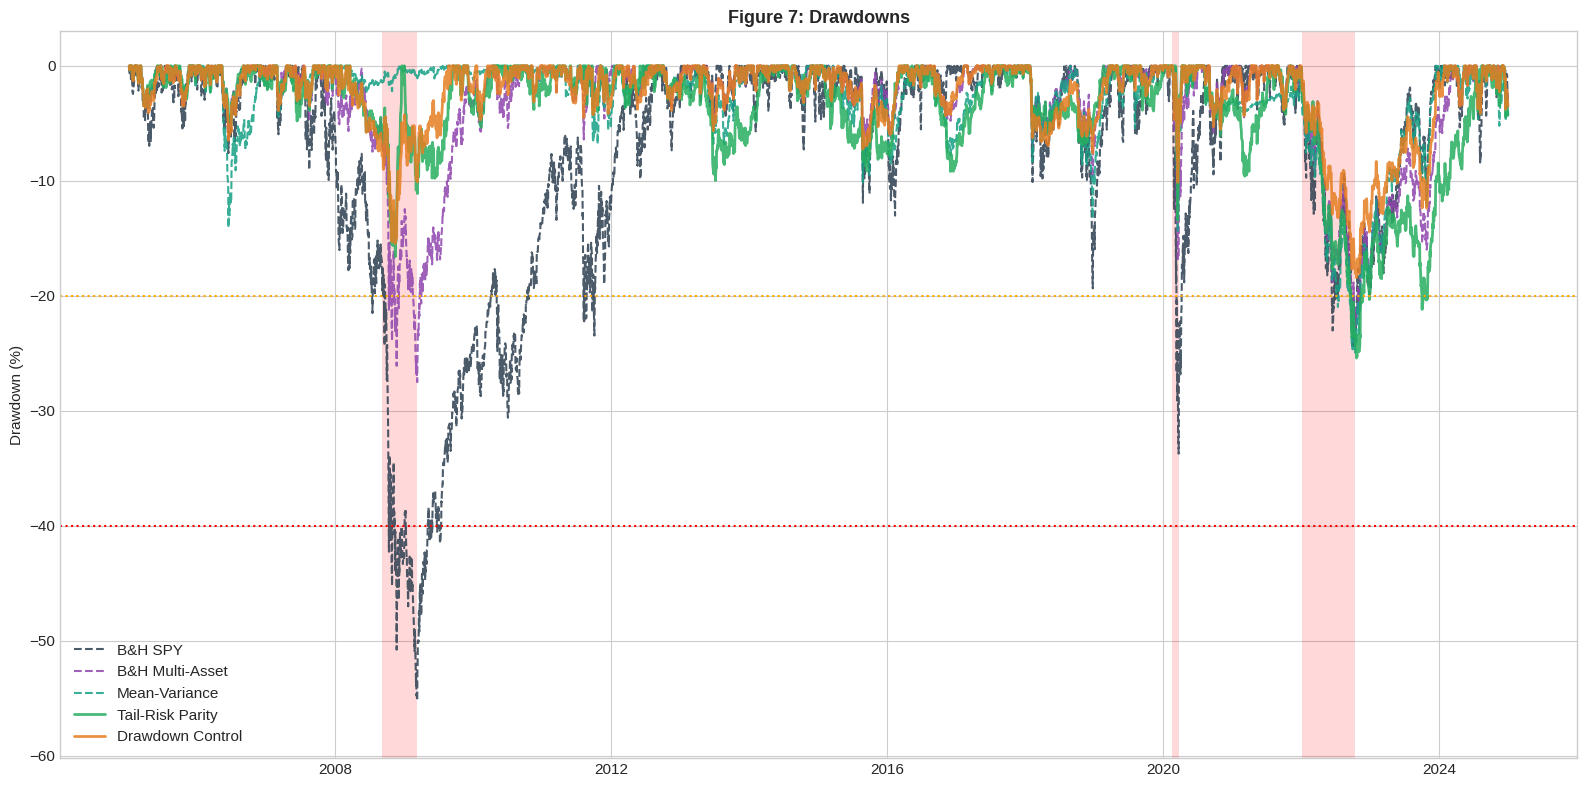

In [28]:
drawdown_df = wealth_df / wealth_df.cummax() - 1

fig, ax = plt.subplots(figsize=(16, 8))
shade_crises(ax)
for name in STRATEGIES:
    is_bm = name in BENCHMARKS
    ax.plot(drawdown_df.index, drawdown_df[name] * 100, label=name, color=COLORS[name],
            ls='--' if is_bm else '-', lw=1.5 if is_bm else 2, alpha=0.85)
ax.axhline(-20, color='orange', ls=':', lw=1.5)
ax.axhline(-40, color='red', ls=':', lw=1.5)
ax.set_ylabel('Drawdown (%)')
ax.set_ylim(min(-60, drawdown_df.min().min() * 100 - 5), 3)
ax.set_title('Figure 7: Drawdowns', fontweight='bold')
ax.legend(loc='lower left')
plt.tight_layout()
save_fig(fig, 'fig07_drawdowns')
plt.show()

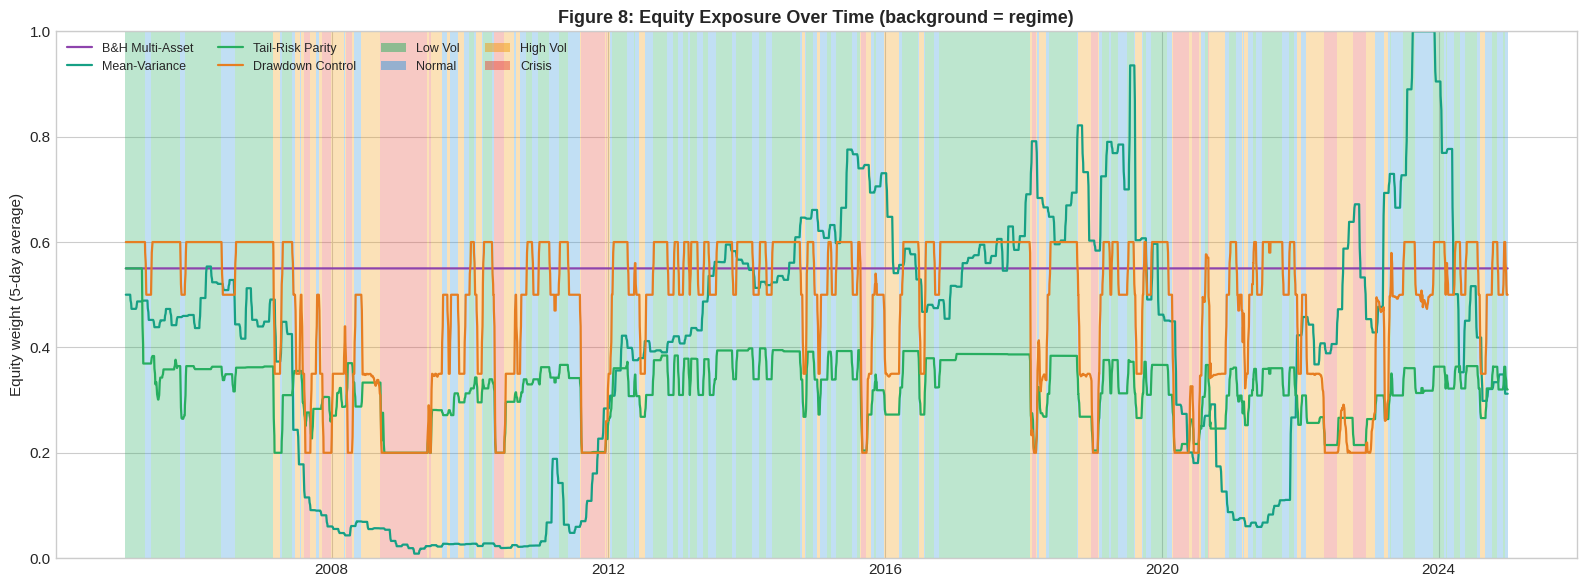

In [29]:
fig, ax = plt.subplots(figsize=(16, 6))
shade_regimes(ax, regime.reindex(bt_index).ffill())
for name in ['B&H Multi-Asset', 'Mean-Variance'] + DYNAMIC_STRATEGIES:
    ax.plot(equity_df.index, equity_df[name].rolling(5).mean(), label=name, color=COLORS[name], lw=1.6)
ax.set_ylabel('Equity weight (5-day average)')
ax.set_ylim(0, 1)
ax.set_title('Figure 8: Equity Exposure Over Time (background = regime)', fontweight='bold')
handles = ax.get_legend_handles_labels()[0] + [Patch(facecolor=REGIME_COLORS[r], alpha=0.5, label=r) for r in REGIME_NAMES]
ax.legend(handles=handles, loc='upper left', ncol=4, fontsize=9)
plt.tight_layout()
save_fig(fig, 'fig08_equity_exposure')
plt.show()

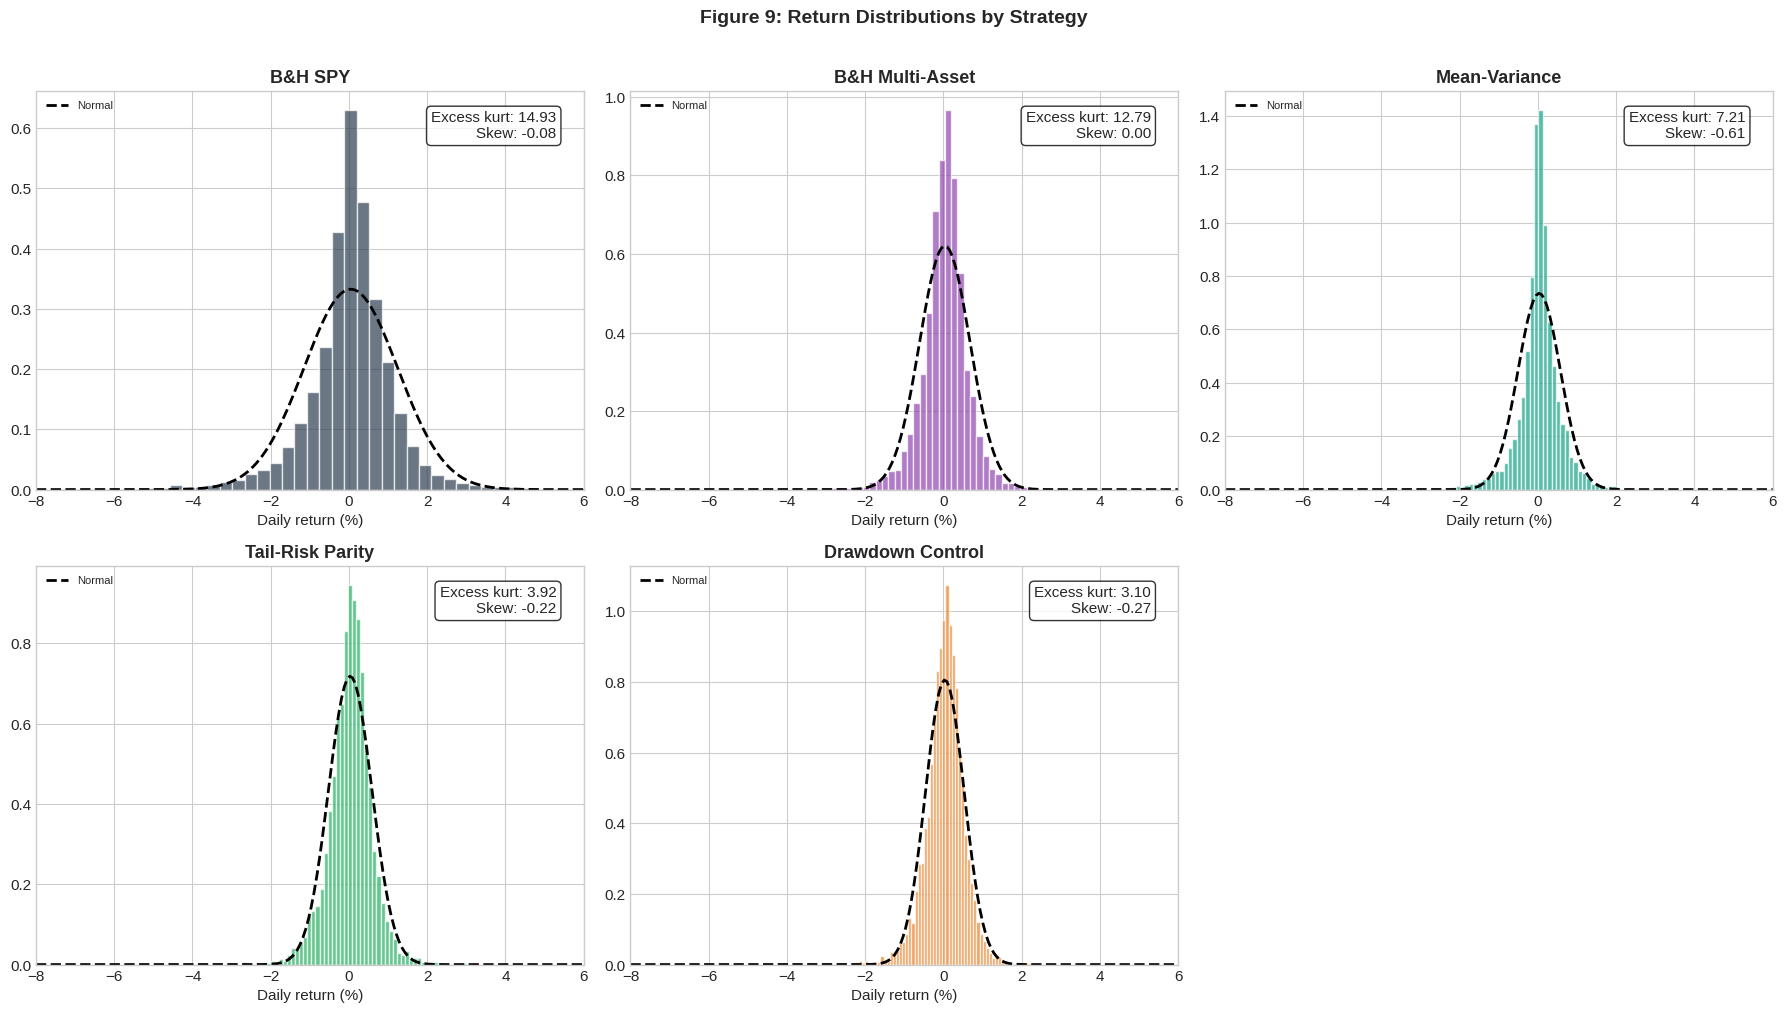

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, name in zip(axes.flat, STRATEGIES):
    rets = returns_df[name].values * 100
    ax.hist(rets, bins=80, density=True, alpha=0.7, color=COLORS[name], edgecolor='white')
    grid = np.linspace(-8, 6, 200)
    ax.plot(grid, norm.pdf(grid, rets.mean(), rets.std()), 'k--', lw=2, label='Normal')
    ax.text(0.95, 0.95, f'Excess kurt: {kurtosis(rets):.2f}\nSkew: {skew(rets):.2f}',
            transform=ax.transAxes, va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_xlim(-8, 6)
    ax.set_xlabel('Daily return (%)')
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=8)
axes.flat[-1].set_visible(False)
fig.suptitle('Figure 9: Return Distributions by Strategy', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig(fig, 'fig09_strategy_distributions')
plt.show()

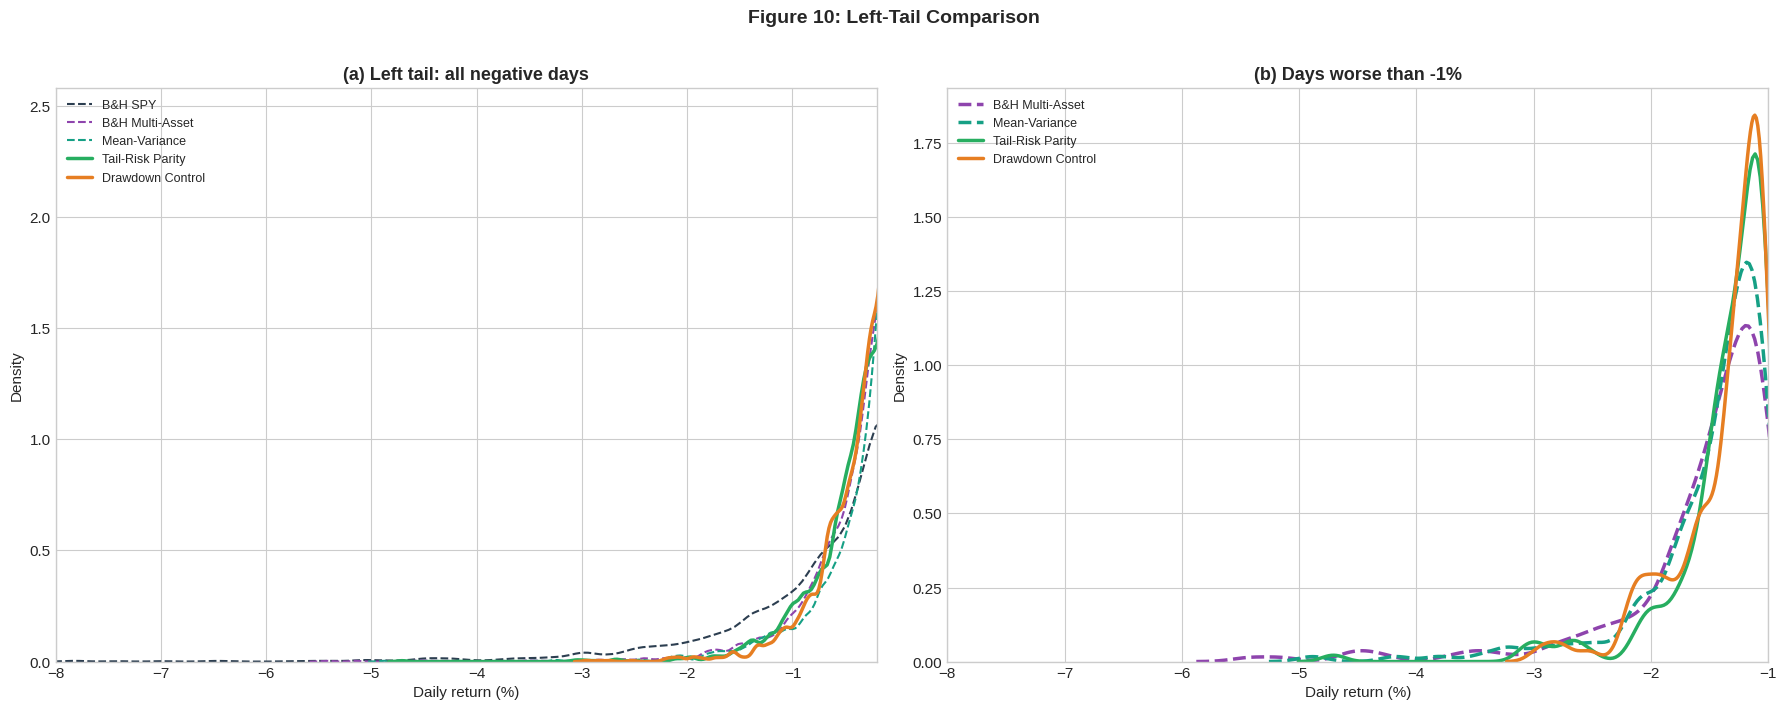

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
for name in STRATEGIES:
    left = returns_df[name].values * 100
    left = left[left < 0]
    is_bm = name in BENCHMARKS
    sns.kdeplot(left, ax=ax, label=name, color=COLORS[name], ls='--' if is_bm else '-',
                lw=1.5 if is_bm else 2.5, bw_adjust=0.5)
ax.set_xlim(-8, -0.2)
ax.set_xlabel('Daily return (%)')
ax.set_title('(a) Left tail: all negative days', fontweight='bold')
ax.legend(fontsize=9, loc='upper left')

ax = axes[1]
for name in ['B&H Multi-Asset', 'Mean-Variance'] + DYNAMIC_STRATEGIES:
    tail = returns_df[name].values * 100
    tail = tail[tail < -1]
    if len(tail) > 10:
        is_bm = name in BENCHMARKS
        sns.kdeplot(tail, ax=ax, label=name, color=COLORS[name], ls='--' if is_bm else '-',
                    lw=2.5, bw_adjust=0.6)
ax.set_xlim(-8, -1)
ax.set_xlabel('Daily return (%)')
ax.set_title('(b) Days worse than -1%', fontweight='bold')
ax.legend(fontsize=9)

fig.suptitle('Figure 10: Left-Tail Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig(fig, 'fig10_left_tail')
plt.show()

## 6. Crisis periods

In [32]:
crisis_rows = []
for crisis, start, end in CRISES:
    window = returns_df.loc[start:end]
    for name in STRATEGIES:
        r = window[name].values
        wealth = np.cumprod(1 + r)
        crisis_rows.append({'Crisis': crisis, 'Strategy': name,
                            'Return (%)': round((wealth[-1] - 1) * 100, 1),
                            'Max DD (%)': round((wealth / np.maximum.accumulate(wealth) - 1).min() * 100, 1),
                            'Worst day (%)': round(r.min() * 100, 2)})
crisis_df = pd.DataFrame(crisis_rows)

for crisis, _, _ in CRISES:
    print(f'\n{crisis}')
    display(crisis_df[crisis_df['Crisis'] == crisis].drop(columns='Crisis').set_index('Strategy'))


GFC


,Return (%),Max DD (%),Worst day (%)
Strategy,,,
B&H SPY,-46.4,-46.0,-9.84
B&H Multi-Asset,-23.5,-23.2,-5.15
Mean-Variance,0.9,-1.7,-0.45
Tail-Risk Parity,-4.0,-13.4,-2.51
Drawdown Control,-4.0,-11.5,-2.74



COVID


,Return (%),Max DD (%),Worst day (%)
Strategy,,,
B&H SPY,-33.4,-33.7,-10.94
B&H Multi-Asset,-16.2,-17.0,-5.43
Mean-Variance,-8.3,-14.5,-4.89
Tail-Risk Parity,-2.5,-13.4,-4.71
Drawdown Control,-7.0,-10.1,-2.95



2022 Bear


,Return (%),Max DD (%),Worst day (%)
Strategy,,,
B&H SPY,-24.1,-24.5,-4.35
B&H Multi-Asset,-22.1,-21.7,-3.16
Mean-Variance,-23.5,-22.6,-3.26
Tail-Risk Parity,-23.3,-22.3,-2.97
Drawdown Control,-17.3,-17.2,-2.17


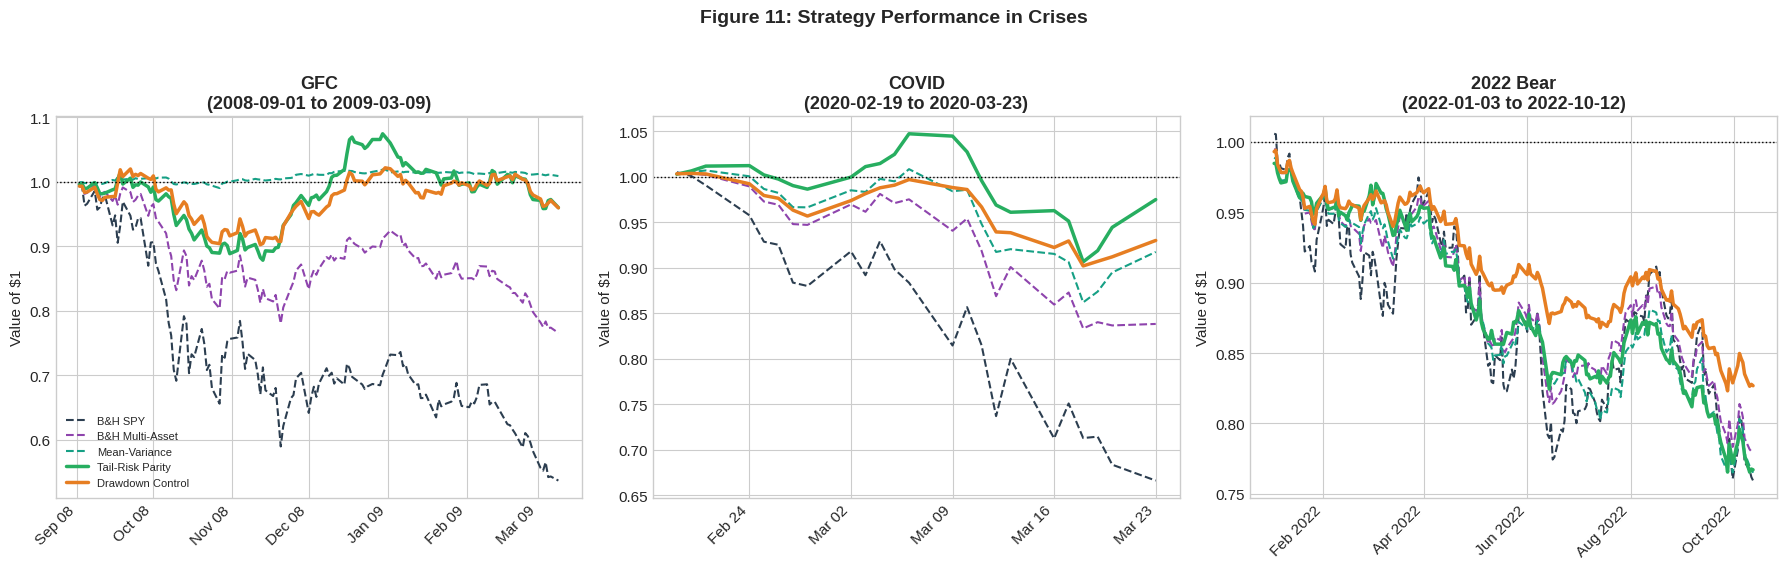

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (crisis, start, end) in zip(axes, CRISES):
    window = returns_df.loc[start:end]
    for name in STRATEGIES:
        is_bm = name in BENCHMARKS
        ax.plot(window.index, (1 + window[name]).cumprod(), label=name, color=COLORS[name],
                ls='--' if is_bm else '-', lw=1.5 if is_bm else 2.5)
    ax.axhline(1, color='black', ls=':', lw=1)
    ax.set_title(f'{crisis}\n({start} to {end})', fontweight='bold')
    ax.set_ylabel('Value of $1')
    if crisis == 'COVID':
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    elif crisis == '2022 Bear':
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
axes[0].legend(loc='lower left', fontsize=8)
fig.suptitle('Figure 11: Strategy Performance in Crises', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
save_fig(fig, 'fig11_crisis_performance')
plt.show()

## 7. Monte Carlo validation

One backtest is one path of history. To see whether the results are robust, the strategies are replayed on thousands of simulated 20-year histories:

1. **Regime path:** a Markov chain with the empirical transition matrix from section 3.3, starting from its stationary distribution.
2. **Returns:** for each regime spell, blocks of 5 consecutive real trading days are drawn from history *in that same regime* (block bootstrap). Only blocks where all 5 days carry that regime label are used, and SPY, TLT, Gold and SHY are drawn together, so their joint behaviour within a regime is preserved.
3. **Transitions between blocks** use the 5-step transition matrix $P^5$, because one block covers five days.
4. **Strategies:** exactly the same functions as in the backtest, acting on the previous day's simulated regime.

One caveat: in the simulation the strategies know the true regime (with a one-day lag), while in the backtest they rely on the HMM's estimate. The simulation therefore shows how the strategies behave if regime detection works well, which is an optimistic setting.

In [34]:
mc_index = regime_int.index.intersection(simple_ret.index)
mc_R = simple_ret.loc[mc_index, ASSETS].values
mc_reg = regime_int.loc[mc_index].values

# Valid block starts per regime: L consecutive days that all belong to that regime.
mc_blocks = {}
for s in range(N_STATES):
    starts = [i for i in range(len(mc_reg) - BLOCK_LENGTH + 1)
              if (mc_reg[i:i + BLOCK_LENGTH] == s).all()]
    if starts:
        mc_blocks[s] = (np.array(starts), BLOCK_LENGTH)
    else:
        # very short-lived regime: fall back to single days
        mc_blocks[s] = (np.where(mc_reg == s)[0], 1)

block_transitions = {L: np.linalg.matrix_power(transition_matrix, L)
                     for L in {L for _, L in mc_blocks.values()}}

pd.DataFrame({'Blocks available': {REGIME_NAMES[s]: len(v[0]) for s, v in mc_blocks.items()},
              'Block length': {REGIME_NAMES[s]: v[1] for s, v in mc_blocks.items()}})

,Blocks available,Block length
Low Vol,1982,5
Normal,992,5
High Vol,758,5
Crisis,560,5


In [35]:
def simulate_path(n_days, rng):
    """Simulate one regime-switching history of asset returns.

    Returns (R, regimes) with the same shapes as the backtest inputs.
    """
    R = np.empty((n_days, len(ASSETS)))
    reg = np.empty(n_days, dtype=int)
    state = rng.choice(N_STATES, p=stationary)
    t = 0
    while t < n_days:
        starts, L = mc_blocks[state]
        i = starts[rng.integers(len(starts))]
        m = min(L, n_days - t)
        R[t:t + m] = mc_R[i:i + m]
        reg[t:t + m] = state
        t += m
        state = rng.choice(N_STATES, p=block_transitions[L][state])
    return R, reg


def run_monte_carlo(n_sims=N_SIMS, seed=SEED):
    """Replay all strategies (except 100% SPY) on n_sims simulated histories.

    Every path has the same length as the backtest. Returns one row of
    metrics per (simulation, strategy).
    """
    rng = np.random.default_rng(seed)
    n_days = len(bt_index)
    rows = []
    for sim in tqdm(range(n_sims), desc='Monte Carlo'):
        R, reg = simulate_path(n_days, rng)
        reg_lag = np.r_[reg[0], reg[:-1]]
        kurt_lag = pd.Series(R[:, 0]).rolling(252).kurt().shift(1).fillna(0.0).values
        sim_results = run_strategies(R, reg_lag, kurt_lag, include_spy=False)
        for name, (rets, _) in sim_results.items():
            rows.append({'Sim': sim, 'Strategy': name, **calculate_metrics(rets)})
    return pd.DataFrame(rows)


mc_results = run_monte_carlo()
print(f'{mc_results["Sim"].nunique()} simulations x {mc_results["Strategy"].nunique()} strategies')

3000 simulations x 4 strategies


In [36]:
mc_strategies = ['B&H Multi-Asset', 'Mean-Variance'] + DYNAMIC_STRATEGIES

for metric in ['CVaR 99% (%)', 'Sharpe', 'Kurtosis', 'Skewness', 'Tail Ratio', 'Max Drawdown (%)']:
    summary = (mc_results.groupby('Strategy')[metric]
               .describe(percentiles=[0.05, 0.5, 0.95])[['mean', 'std', '5%', '50%', '95%']]
               .reindex(mc_strategies).round(3))
    print(f'\n{metric}')
    display(summary)


CVaR 99% (%)


,mean,std,5%,50%,95%
Strategy,,,,,
B&H Multi-Asset,2.553,0.361,1.98,2.54,3.15
Mean-Variance,2.968,0.480,2.26,2.93,3.81
Tail-Risk Parity,2.000,0.187,1.71,1.99,2.32
Drawdown Control,1.659,0.135,1.44,1.66,1.89



Sharpe


,mean,std,5%,50%,95%
Strategy,,,,,
B&H Multi-Asset,0.864,0.265,0.432,0.861,1.300
Mean-Variance,0.719,0.292,0.242,0.718,1.184
Tail-Risk Parity,0.929,0.258,0.504,0.926,1.353
Drawdown Control,1.156,0.264,0.729,1.158,1.594



Kurtosis


...

,mean,std,5%,50%,95%
Strategy,,,,,
B&H Multi-Asset,0.043,0.382,-0.577,0.046,0.671
Mean-Variance,-0.106,0.527,-0.939,-0.138,0.788
Tail-Risk Parity,-0.176,0.179,-0.462,-0.182,0.122
Drawdown Control,-0.176,0.160,-0.425,-0.182,0.092



Tail Ratio


,mean,std,5%,50%,95%
Strategy,,,,,
B&H Multi-Asset,1.036,0.042,0.966,1.036,1.105
Mean-Variance,1.026,0.049,0.950,1.025,1.111
Tail-Risk Parity,1.012,0.037,0.952,1.011,1.075
Drawdown Control,1.047,0.037,0.983,1.048,1.107



Max Drawdown (%)


,mean,std,5%,50%,95%
Strategy,,,,,
B&H Multi-Asset,-21.960,6.535,-34.005,-21.0,-13.195
Mean-Variance,-26.152,8.679,-42.605,-24.6,-14.500
Tail-Risk Parity,-17.770,4.754,-26.800,-17.0,-11.400
Drawdown Control,-14.069,3.814,-21.400,-13.4,-9.100


In [37]:
def pivot(metric):
    """Simulations as rows, strategies as columns, for one metric."""
    return mc_results.pivot(index='Sim', columns='Strategy', values=metric)


cvar, sharpe, kurt_mc = pivot('CVaR 99% (%)'), pivot('Sharpe'), pivot('Kurtosis')
tail, skew_mc, mdd = pivot('Tail Ratio'), pivot('Skewness'), pivot('Max Drawdown (%)')

def outperformance(benchmark):
    """Share of simulations (%) in which each dynamic strategy beats the benchmark."""
    out = pd.DataFrame({
        'P(CVaR 99% < BM)': [(cvar[s] < cvar[benchmark]).mean() for s in DYNAMIC_STRATEGIES],
        'P(Sharpe > BM)': [(sharpe[s] > sharpe[benchmark]).mean() for s in DYNAMIC_STRATEGIES],
        'P(Kurtosis < BM)': [(kurt_mc[s] < kurt_mc[benchmark]).mean() for s in DYNAMIC_STRATEGIES],
        'P(Skew > BM)': [(skew_mc[s] > skew_mc[benchmark]).mean() for s in DYNAMIC_STRATEGIES],
        'P(Tail Ratio > BM)': [(tail[s] > tail[benchmark]).mean() for s in DYNAMIC_STRATEGIES],
        'P(Max DD smaller than BM)': [(mdd[s] > mdd[benchmark]).mean() for s in DYNAMIC_STRATEGIES],
    }, index=DYNAMIC_STRATEGIES) * 100
    out.index.name = 'Strategy (% of simulations)'
    return out.round(1)


outperf = {bm: outperformance(bm) for bm in [BENCHMARK, 'Mean-Variance']}
for bm, table in outperf.items():
    print(f'\nvs. {bm}')
    display(table)


vs. B&H Multi-Asset


,P(CVaR 99% < BM),P(Sharpe > BM),P(Kurtosis < BM),P(Skew > BM),P(Tail Ratio > BM),P(Max DD smaller than BM)
Strategy (% of simulations),,,,,,
Tail-Risk Parity,99.7,63.6,99.9,25.6,26.1,78.9
Drawdown Control,100.0,99.5,99.9,25.0,62.1,97.9



vs. Mean-Variance


,P(CVaR 99% < BM),P(Sharpe > BM),P(Kurtosis < BM),P(Skew > BM),P(Tail Ratio > BM),P(Max DD smaller than BM)
Strategy (% of simulations),,,,,,
Tail-Risk Parity,99.5,84.8,99.0,46.7,37.8,89.9
Drawdown Control,99.9,99.4,99.7,47.2,68.8,97.6


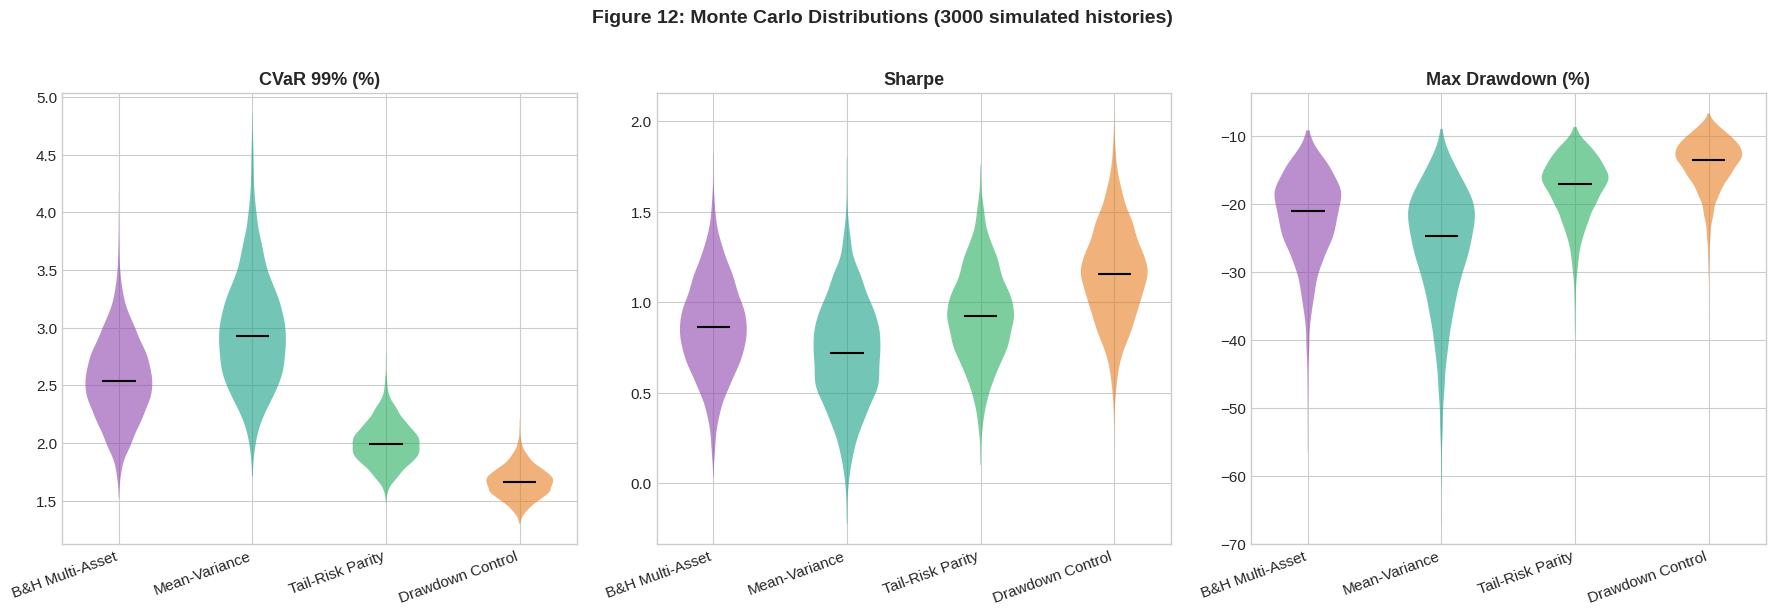

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, metric in zip(axes, ['CVaR 99% (%)', 'Sharpe', 'Max Drawdown (%)']):
    data = [mc_results.loc[mc_results['Strategy'] == s, metric].values for s in mc_strategies]
    parts = ax.violinplot(data, showmedians=True, showextrema=False)
    for body, s in zip(parts['bodies'], mc_strategies):
        body.set_facecolor(COLORS[s])
        body.set_alpha(0.6)
    parts['cmedians'].set_color('black')
    ax.set_xticks(range(1, len(mc_strategies) + 1))
    ax.set_xticklabels(mc_strategies, rotation=20, ha='right')
    ax.set_title(metric, fontweight='bold')
fig.suptitle(f'Figure 12: Monte Carlo Distributions ({mc_results["Sim"].nunique()} simulated histories)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'fig12_monte_carlo')
plt.show()

## 8. Summary

In [39]:
summary_cols = ['Annual Return (%)', 'Sharpe', 'Kurtosis', 'Skewness', 'Tail Ratio',
                'CVaR 99% (%)', 'Max Drawdown (%)']
display(metrics_df.loc[['B&H Multi-Asset', 'Mean-Variance'] + DYNAMIC_STRATEGIES, summary_cols])

print('Answer to the research question (backtest 2005-2024; Monte Carlo share in brackets):')
for bm_name in [BENCHMARK, 'Mean-Variance']:
    bm = metrics_df.loc[bm_name]
    print(f'\nvs. {bm_name}')
    for name in DYNAMIC_STRATEGIES:
        m = metrics_df.loc[name]
        es_change = (m['CVaR 99% (%)'] / bm['CVaR 99% (%)'] - 1) * 100
        p_es = outperf[bm_name].loc[name, 'P(CVaR 99% < BM)']
        p_sh = outperf[bm_name].loc[name, 'P(Sharpe > BM)']
        print(f'  {name}: ES 99% {m["CVaR 99% (%)"]:.2f}% vs {bm["CVaR 99% (%)"]:.2f}% '
              f'({es_change:+.1f}%, lower in {p_es:.0f}% of simulations); '
              f'Sharpe {m["Sharpe"]:.2f} vs {bm["Sharpe"]:.2f} (higher in {p_sh:.0f}%)')

,Annual Return (%),Sharpe,Kurtosis,Skewness,Tail Ratio,CVaR 99% (%),Max Drawdown (%)
Strategy,,,,,,,
B&H Multi-Asset,8.52,0.639,12.79,0.003,1.009,2.59,-27.5
Mean-Variance,7.77,0.670,7.21,-0.612,1.010,2.25,-24.9
Tail-Risk Parity,7.86,0.665,3.92,-0.224,0.969,1.93,-25.4
Drawdown Control,8.67,0.848,3.10,-0.268,0.988,1.78,-18.4


Answer to the research question (backtest 2005-2024; Monte Carlo share in brackets):

vs. B&H Multi-Asset
  Tail-Risk Parity: ES 99% 1.93% vs 2.59% (-25.5%, lower in 100% of simulations); Sharpe 0.67 vs 0.64 (higher in 64%)
  Drawdown Control: ES 99% 1.78% vs 2.59% (-31.3%, lower in 100% of simulations); Sharpe 0.85 vs 0.64 (higher in 100%)

vs. Mean-Variance
  Tail-Risk Parity: ES 99% 1.93% vs 2.25% (-14.2%, lower in 100% of simulations); Sharpe 0.67 vs 0.67 (higher in 85%)
  Drawdown Control: ES 99% 1.78% vs 2.25% (-20.9%, lower in 100% of simulations); Sharpe 0.85 vs 0.67 (higher in 99%)
